# Modelo Predictivo — Shock Hemorrágico Postoperatorio

**Variables base (6):** `EDAD`, `GENERO`, `HB_PREQX`, `HIPERTENSION`, `CANCER_ACTIVO`, `SANGRADO_MAYOR`  
*(criterio: ≥ 110 pacientes con valor > 0 · `SANGRADO_MAYOR` incluida por justificación clínica)*  
**Feature engineering:** `HB_x_SANGRADO` (interacción × clínica), `EDAD2` (no linealidad) → **8 features totales**  
**Variable objetivo:** `SHOCK` (0 = no shock, 1 = shock)  
**Dataset:** 1,324 pacientes · 427 positivos (32.3%) · 897 negativos (67.7%)  
**Excluidas:**  
- `MUERTE.1` — outcome posterior al shock (data leakage)
- `CODIGO` — identificador único
- Variables con < 110 positivos sin justificación clínica diferencial: `ACT_FISICA_METS` (66), `DIABETES` (56), `HIPOTIROIDISMO` (55), `OBESIDAD` (42), `TABAQUISMO` (30), `ERC` (29) y 7 más

**Modelos evaluados (11):** LogReg-LASSO, LogReg-Ridge, LogReg-ElasticNet, DecisionTree, RandomForest, XGBoost, LightGBM, SVM-RBF, Stacking, CatBoost, EBM

**Métricas de evaluación:**
| Métrica | Por qué se usa |
|---|---|
| AUC-ROC + IC95% Bootstrap | Capacidad discriminativa global con incertidumbre estimada |
| F1-Score | Balance precisión/sensibilidad, robusto ante desbalance moderado |
| Cohen's Kappa | Acuerdo ajustado por azar, penaliza aciertos por prevalencia |
| Hosmer-Lemeshow | Calibración formal de probabilidades absolutas |
| Decision Curve Analysis | Beneficio neto clínico en función del umbral de intervención |

**Validación:** Cross-validation estratificada 5-fold · Bootstrap 1000 iteraciones

## 1. Importaciones

In [100]:
import warnings
warnings.filterwarnings('ignore')

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    make_scorer, roc_auc_score, f1_score, cohen_kappa_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.utils import resample as sk_resample
from scipy.stats import chi2 as chi2_dist

import xgboost as xgb
import lightgbm as lgb

try:
    from catboost import CatBoostClassifier
    _has_catboost = True
except ImportError:
    _has_catboost = False
    print('[AVISO] catboost no instalado. Ejecuta: pip install catboost')

try:
    from interpret.glassbox import ExplainableBoostingClassifier
    _has_ebm = True
except ImportError:
    _has_ebm = False
    print('[AVISO] interpret no instalado. Ejecuta: pip install interpret')

import shap

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('Entorno listo.')

Entorno listo.


## 2. Carga de datos

In [101]:
df = pd.read_csv('shock.csv')
df_raw = df.copy()

# Features con >= 110 casos con valor > 0
# Continuas (EDAD, HB_PREQX): incluidas siempre
# Binarias/ordinales >= 110: GENERO (468), HIPERTENSION (175), CANCER_ACTIVO (111)
# Excepción clínica: SANGRADO_MAYOR (100) — predictor directo de shock hemorrágico
# Excluidas (n < 110 y sin justificación clínica diferencial):
#   ACT_FISICA_METS (66), DIABETES (56), HIPOTIROIDISMO (55), OBESIDAD (42),
#   TABAQUISMO (30), ERC (29), ENF_CEREBROVASCULAR (10), ASMA (8),
#   INMUNOSUPRESION (8), EPOC (9), FALLA_CARDIACA (7),
#   ENFERMEDAD_CORONARIA (11), HIPERTENSION_PULMONAR (3)
FEATURES_BASE = [
    'EDAD',
    'GENERO',
    'HB_PREQX',
    'HIPERTENSION',
    'CANCER_ACTIVO',
    'SANGRADO_MAYOR',   # excepción clínica (n=100, OR esperado muy alto)
    'ACT_FISICA_METS',
    'DIABETES',
    'HIPOTIROIDISMO',
    'OBESIDAD',
    'TABAQUISMO',
    'ERC',
    'ENF_CEREBROVASCULAR',
    'ASMA',
    'INMUNOSUPRESION',
    'EPOC',
    'FALLA_CARDIACA',
    'ENFERMEDAD_CORONARIA',
    'HIPERTENSION_PULMONAR',
]
TARGET = 'SHOCK'

# Limpieza: todas las comorbilidades/categóricas se tratan como booleanas (0/1).
# Si aparecen valores > 1 (p.ej., 2), se recodifican a 1.
BOOL_COLS = [c for c in FEATURES_BASE if c not in {'EDAD', 'HB_PREQX'}]
bad_cols = {}
for col in BOOL_COLS:
    s_raw = pd.to_numeric(df_raw[col], errors='coerce').fillna(0)
    n_gt1 = int((s_raw > 1).sum())
    if n_gt1:
        bad_cols[col] = n_gt1
    s = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df[col] = (s > 0).astype(int)
if bad_cols:
    print('Aviso: valores >1 recodificados a 1 en:', bad_cols)

X_all = df[FEATURES_BASE].copy()
y_all = df[TARGET].copy().astype(int)

# Feature engineering
# HB_x_SANGRADO: riesgo multiplicativo de Hb baja + sangrado activo
# EDAD2: efecto no lineal de la edad en la reserva fisiológica
X_all['HB_x_SANGRADO'] = X_all['HB_PREQX'] * X_all['SANGRADO_MAYOR']
X_all['EDAD2']         = X_all['EDAD'] ** 2

# ── Split final (holdout) ───────────────────────────────────────────────────
# Se reserva 10% como TEST final. Todo el desarrollo (CV, selección de modelo, umbral, calibración)
# se realiza exclusivamente en TRAIN (90%).
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.10, stratify=y_all, random_state=RANDOM_STATE
)

# A partir de aquí, el pipeline trabaja SOLO con TRAIN
X = X_train
y = y_train

FEATURES = list(X.columns)

print(f'Pacientes totales (dataset completo): {len(df)}')
print(f'  SHOCK = 1: {int(y_all.sum())} ({y_all.mean()*100:.1f}%)')
print(f'  SHOCK = 0: {int((1-y_all).sum())} ({(1-y_all).mean()*100:.1f}%)')
print(f'\nSplit holdout: TEST=10% (estratificado)')
print(f'  TRAIN: {len(X_train)} | SHOCK=1: {int(y_train.sum())} ({y_train.mean()*100:.1f}%)')
print(f'  TEST : {len(X_test)} | SHOCK=1: {int(y_test.sum())} ({y_test.mean()*100:.1f}%)')
print(f'\nValores faltantes (TRAIN): {X.isnull().sum().sum()}')
print(f'\nFeatures base         ({len(FEATURES_BASE)}): {FEATURES_BASE}')
print(f'Features + ingeniería ({len(FEATURES)}): {FEATURES}')

Aviso: valores >1 recodificados a 1 en: {'TABAQUISMO': 11, 'FALLA_CARDIACA': 6}
Pacientes totales (dataset completo): 1324
  SHOCK = 1: 427 (32.3%)
  SHOCK = 0: 897 (67.7%)

Split holdout: TEST=10% (estratificado)
  TRAIN: 1191 | SHOCK=1: 384 (32.2%)
  TEST : 133 | SHOCK=1: 43 (32.3%)

Valores faltantes (TRAIN): 0

Features base         (19): ['EDAD', 'GENERO', 'HB_PREQX', 'HIPERTENSION', 'CANCER_ACTIVO', 'SANGRADO_MAYOR', 'ACT_FISICA_METS', 'DIABETES', 'HIPOTIROIDISMO', 'OBESIDAD', 'TABAQUISMO', 'ERC', 'ENF_CEREBROVASCULAR', 'ASMA', 'INMUNOSUPRESION', 'EPOC', 'FALLA_CARDIACA', 'ENFERMEDAD_CORONARIA', 'HIPERTENSION_PULMONAR']
Features + ingeniería (21): ['EDAD', 'GENERO', 'HB_PREQX', 'HIPERTENSION', 'CANCER_ACTIVO', 'SANGRADO_MAYOR', 'ACT_FISICA_METS', 'DIABETES', 'HIPOTIROIDISMO', 'OBESIDAD', 'TABAQUISMO', 'ERC', 'ENF_CEREBROVASCULAR', 'ASMA', 'INMUNOSUPRESION', 'EPOC', 'FALLA_CARDIACA', 'ENFERMEDAD_CORONARIA', 'HIPERTENSION_PULMONAR', 'HB_x_SANGRADO', 'EDAD2']


## 3. Distribución y asociación de variables

Se incluyen **todas las variables disponibles con datos completos** (1,324/1,324 registros por variable).  
Excluidas únicamente: `CODIGO` (ID único), `MUERTE.1` (outcome posterior al shock — data leakage), `SHOCK` (target).

- Variables continuas: `EDAD`, `HB_PREQX`
- Variables binarias (0/1): `GENERO`, `ACT_FISICA_METS`, `HIPERTENSION`, `DIABETES`, `ENFERMEDAD_CORONARIA`, `HIPOTIROIDISMO`, `ERC`, `INMUNOSUPRESION`, `OBESIDAD`, `HIPERTENSION_PULMONAR`, `EPOC`, `ASMA`, `ENF_CEREBROVASCULAR`, `CANCER_ACTIVO`, `SANGRADO_MAYOR`, `FALLA_CARDIACA`, `TABAQUISMO`

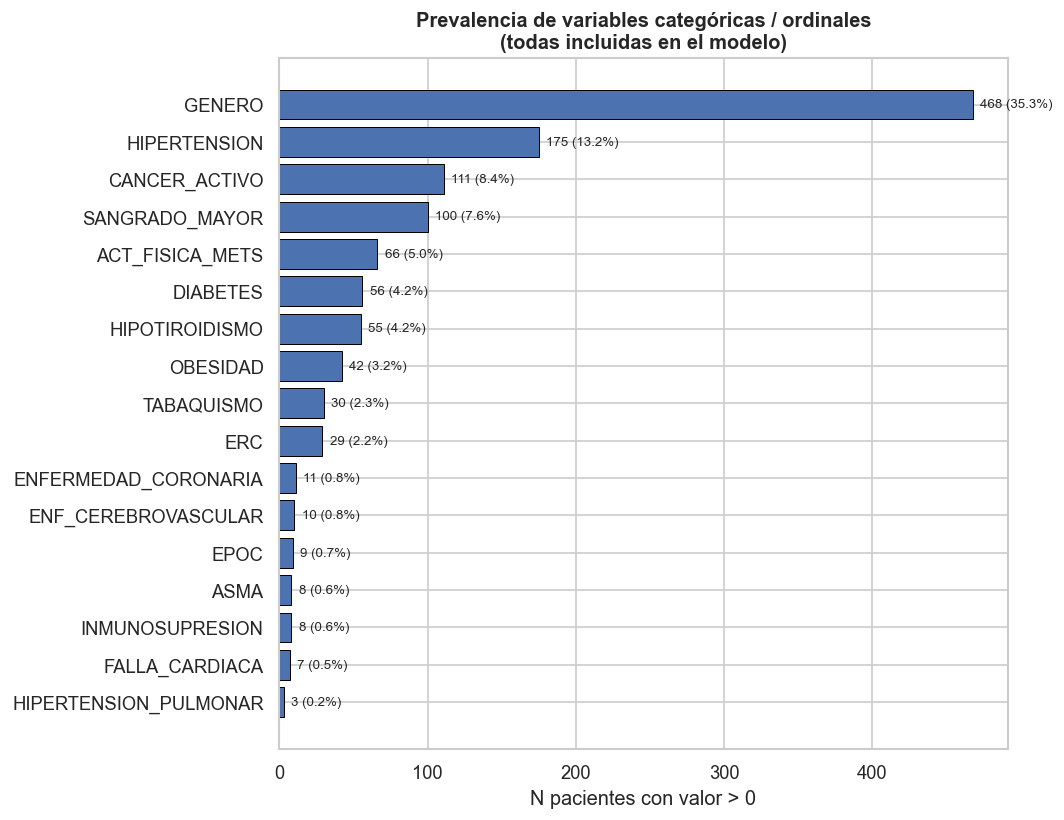

In [102]:
# 3.1 Prevalencia de variables categóricas/ordinales incluidas en el modelo
cat_cols_plot = [c for c in FEATURES_BASE if c not in ['EDAD', 'HB_PREQX']]

prev_df = pd.DataFrame({
    'Variable': cat_cols_plot,
    'N_positivo': [int((df[c] > 0).sum()) for c in cat_cols_plot],
    'Prevalencia_%': [(df[c] > 0).mean() * 100 for c in cat_cols_plot],
}).sort_values('N_positivo', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(prev_df['Variable'], prev_df['N_positivo'],
               color='#4C72B0', edgecolor='black', linewidth=0.6)
ax.set_xlabel('N pacientes con valor > 0')
ax.set_title('Prevalencia de variables categóricas / ordinales\n(todas incluidas en el modelo)',
             fontweight='bold')
for bar, n, pct in zip(bars, prev_df['N_positivo'], prev_df['Prevalencia_%']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{n} ({pct:.1f}%)', va='center', fontsize=8)
plt.tight_layout()
plt.show()

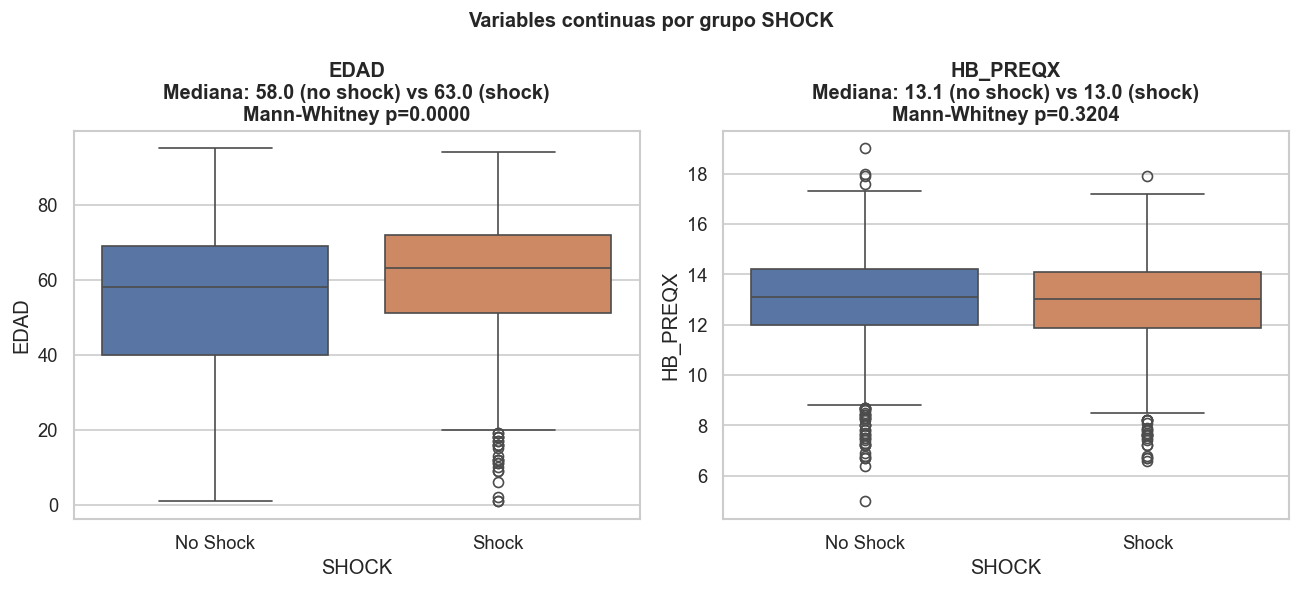

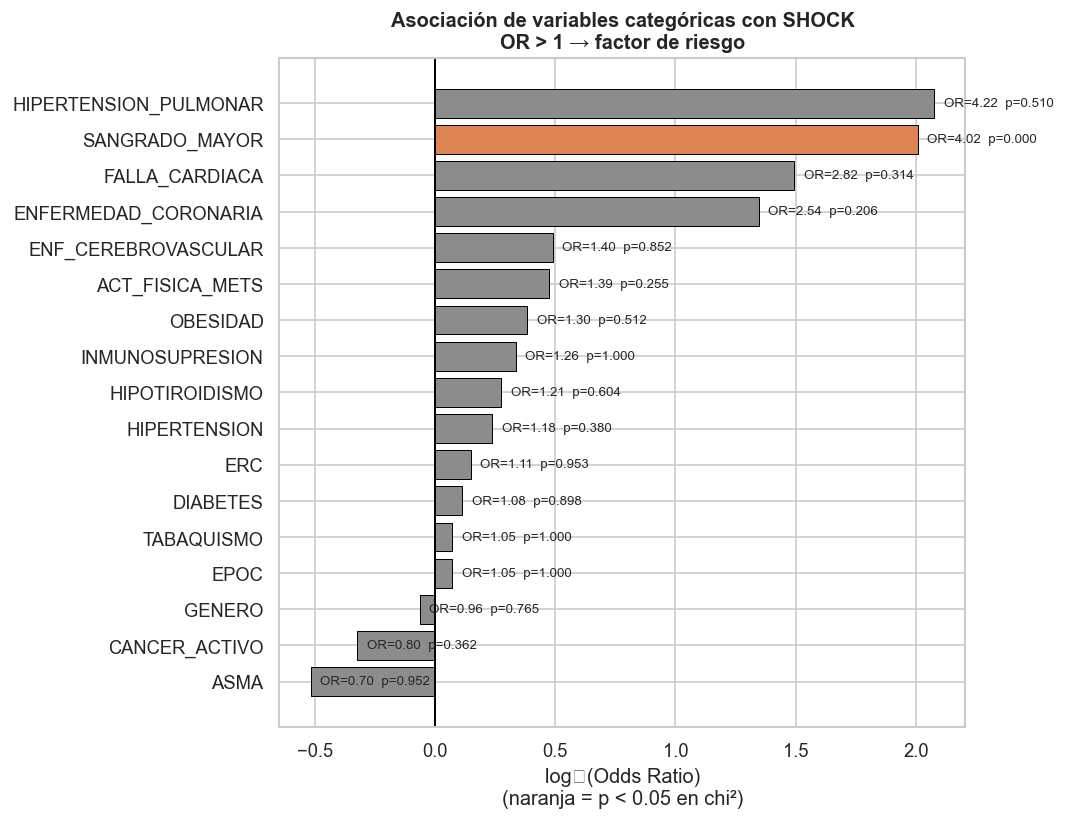


── Tabla OR — variables categóricas / ordinales ──
             Variable    OR     p  %Shock si +  %Shock si -
                 ASMA 0.699 0.952       25.000       32.295
        CANCER_ACTIVO 0.799 0.362       27.928       32.646
               GENERO 0.956 0.765       31.624       32.593
                 EPOC 1.051 1.000       33.333       32.243
           TABAQUISMO 1.052 1.000       33.333       32.226
             DIABETES 1.082 0.898       33.929       32.177
                  ERC 1.108 0.953       34.483       32.201
         HIPERTENSION 1.179 0.380       35.429       31.767
       HIPOTIROIDISMO 1.210 0.604       36.364       32.072
      INMUNOSUPRESION 1.262 1.000       37.500       32.219
             OBESIDAD 1.304 0.512       38.095       32.059
      ACT_FISICA_METS 1.389 0.255       39.394       31.876
  ENF_CEREBROVASCULAR 1.404 0.852       40.000       32.192
 ENFERMEDAD_CORONARIA 2.543 0.206       54.545       32.064
       FALLA_CARDIACA 2.818 0.314       57.143  

In [103]:
from scipy.stats import mannwhitneyu, chi2_contingency

# 3.2a Variables continuas — boxplot por grupo SHOCK
fig, ax_cont = plt.subplots(1, 2, figsize=(11, 5))
for axis, var in zip(ax_cont, ['EDAD', 'HB_PREQX']):
    sns.boxplot(data=df, x='SHOCK', y=var, ax=axis,
                palette={0: '#4C72B0', 1: '#DD8452'}, hue='SHOCK', legend=False)
    _, p = mannwhitneyu(df[df.SHOCK == 0][var], df[df.SHOCK == 1][var])
    m0 = df[df.SHOCK == 0][var].median()
    m1 = df[df.SHOCK == 1][var].median()
    axis.set_title(f'{var}\nMediana: {m0:.1f} (no shock) vs {m1:.1f} (shock)\nMann-Whitney p={p:.4f}',
                   fontweight='bold')
    axis.set_xticklabels(['No Shock', 'Shock'])
fig.suptitle('Variables continuas por grupo SHOCK', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3.2b Variables categóricas/ordinales — Odds Ratio y % shock por grupo
cat_vars = [c for c in FEATURES_BASE if c not in ['EDAD', 'HB_PREQX']]
odds_rows = []
for var in cat_vars:
    ct = pd.crosstab(df[var] > 0, df['SHOCK'])
    if ct.shape == (2, 2):
        a = ct.loc[True,  1]; b = ct.loc[True,  0]
        c = ct.loc[False, 1]; d = ct.loc[False, 0]
        OR = (a * d) / (b * c) if (b * c) > 0 else np.nan
        chi2_stat, p_val, _, _ = chi2_contingency(ct)
        odds_rows.append({
            'Variable':     var,
            'OR':           OR,
            'p':            p_val,
            '%Shock si +':  a / (a + b) * 100 if (a + b) > 0 else np.nan,
            '%Shock si -':  c / (c + d) * 100 if (c + d) > 0 else np.nan,
        })

odds_df = pd.DataFrame(odds_rows).sort_values('OR', ascending=True).dropna(subset=['OR'])

fig2, ax2 = plt.subplots(figsize=(9, 7))
bar_colors = ['#DD8452' if p < 0.05 else '#8C8C8C' for p in odds_df['p']]
ax2.barh(odds_df['Variable'], np.log2(odds_df['OR']),
         color=bar_colors, edgecolor='black', linewidth=0.6)
ax2.axvline(0, color='black', lw=1.2)
ax2.set_xlabel('log₂(Odds Ratio)\n(naranja = p < 0.05 en chi²)')
ax2.set_title('Asociación de variables categóricas con SHOCK\nOR > 1 → factor de riesgo',
              fontweight='bold')
for i, row in enumerate(odds_df.itertuples()):
    ax2.text(np.log2(row.OR) + 0.04, i,
             f'OR={row.OR:.2f}  p={row.p:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\n── Tabla OR — variables categóricas / ordinales ──')
print(odds_df[['Variable', 'OR', 'p', '%Shock si +', '%Shock si -']].to_string(
    index=False, float_format='%.3f'))

## 4. Definición de modelos

| Modelo | Familia | Regularización / Control de overfitting |
|---|---|---|
| LogReg-LASSO | Lineal | L1 — selección de features |
| LogReg-Ridge | Lineal | L2 — shrinkage |
| LogReg-ElasticNet | Lineal | L1+L2 combinado |
| **DecisionTree** | **Árbol** | **`max_depth=4`, `min_samples_leaf` — reglas clínicas legibles** |
| RandomForest | Árboles | Bagging + `min_samples_leaf` |
| XGBoost | Boosting | `reg_alpha`, `reg_lambda`, `subsample` |
| LightGBM | Boosting | igual que XGBoost, más rápido |
| SVM-RBF | Kernel | margen máximo + `C` — nativo bien calibrado |
| Stacking | Ensemble | meta-learner logístico sobre 4 base models |
| CatBoost | Boosting | oblivious trees, manejo nativo de desbalance |
| EBM | GAM | interpretable, interacciones de pares — nativo bien calibrado |

`scale_pos_weight` / `class_weight='balanced'` corrigen el desbalance 67/33 en todos los modelos.  
**Sección 13.2**: Los modelos con mala calibración reciben Platt scaling post-hoc.

In [104]:
neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos = neg / pos
print(f'Ratio neg/pos (scale_pos_weight): {scale_pos:.3f}')

# Estimadores base para Stacking (definidos independientemente para evitar referencia circular)
_base_estimators = [
    ('logreg', Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            penalty='l2', solver='lbfgs', C=0.1,
            class_weight='balanced', max_iter=10000, random_state=RANDOM_STATE
        ))
    ])),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=4, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    )),
    ('xgb', xgb.XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, scale_pos_weight=scale_pos,
        eval_metric='auc', random_state=RANDOM_STATE, verbosity=0
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, scale_pos_weight=scale_pos,
        random_state=RANDOM_STATE, verbose=-1
    )),
]

models = {
    'LogReg-LASSO': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegressionCV(
            Cs=50, cv=5, penalty='l1', solver='saga',
            scoring='roc_auc', class_weight='balanced',
            max_iter=10000, random_state=RANDOM_STATE
        ))
    ]),

    'LogReg-Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegressionCV(
            Cs=50, cv=5, penalty='l2', solver='lbfgs',
            scoring='roc_auc', class_weight='balanced',
            max_iter=10000, random_state=RANDOM_STATE
        ))
    ]),

    'LogReg-ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegressionCV(
            Cs=50, cv=5, penalty='elasticnet', solver='saga',
            l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
            scoring='roc_auc', class_weight='balanced',
            max_iter=10000, random_state=RANDOM_STATE
        ))
    ]),

    'DecisionTree': DecisionTreeClassifier(
        max_depth=4, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ),

    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=4, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, reg_alpha=0.1, reg_lambda=1.0,
        eval_metric='auc', random_state=RANDOM_STATE, verbosity=0
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, reg_alpha=0.1, reg_lambda=1.0,
        random_state=RANDOM_STATE, verbose=-1
    ),

    'SVM-RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=1.0, gamma='scale',
            class_weight='balanced', probability=True,
            random_state=RANDOM_STATE
        ))
    ]),

    'Stacking': StackingClassifier(
        estimators=_base_estimators,
        final_estimator=LogisticRegression(
            C=1.0, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE
        ),
        cv=5, n_jobs=1, passthrough=False
    ),
}

if _has_catboost:
    models['CatBoost'] = CatBoostClassifier(
        iterations=300, depth=4, learning_rate=0.05,
        auto_class_weights='Balanced',
        random_seed=RANDOM_STATE, verbose=0
    )

if _has_ebm:
    models['EBM'] = ExplainableBoostingClassifier(
        max_bins=256, interactions=3,
        random_state=RANDOM_STATE
    )

# Paleta dinámica
_tab = (
    ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
     '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
    + [f'#{r:02x}{g:02x}{b:02x}'
       for r, g, b in [(214,39,40),(148,103,189),(140,86,75),
                       (227,119,194),(127,127,127),(188,189,34),(23,190,207)]]
)
palette = _tab[:len(models)]

print(f'\nModelos configurados ({len(models)}):')
for i, name in enumerate(models, 1):
    print(f'  {i:2}. {name}')

Ratio neg/pos (scale_pos_weight): 2.102

Modelos configurados (11):
   1. LogReg-LASSO
   2. LogReg-Ridge
   3. LogReg-ElasticNet
   4. DecisionTree
   5. RandomForest
   6. XGBoost
   7. LightGBM
   8. SVM-RBF
   9. Stacking
  10. CatBoost
  11. EBM


## 5. Validación cruzada estratificada 5-fold

In [105]:
kappa_scorer = make_scorer(cohen_kappa_score)
scoring = {
    'AUC-ROC' : 'roc_auc',
    'F1'      : 'f1',
    'Kappa'   : kappa_scorer,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    print(f'Evaluando {name}...', end=' ', flush=True)
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring,
                            return_train_score=False, n_jobs=-1)
    cv_results[name] = scores
    auc = scores['test_AUC-ROC'].mean()
    f1  = scores['test_F1'].mean()
    k   = scores['test_Kappa'].mean()
    print(f'AUC={auc:.3f}  F1={f1:.3f}  κ={k:.3f}')

print('\nCV completado.')

Evaluando LogReg-LASSO... AUC=0.635  F1=0.433  κ=0.134
Evaluando LogReg-Ridge... AUC=0.608  F1=0.427  κ=0.126
Evaluando LogReg-ElasticNet... AUC=0.635  F1=0.430  κ=0.135
Evaluando DecisionTree... AUC=0.639  F1=0.471  κ=0.133
Evaluando RandomForest... AUC=0.628  F1=0.412  κ=0.109
Evaluando XGBoost... AUC=0.586  F1=0.424  κ=0.092
Evaluando LightGBM... AUC=0.584  F1=0.423  κ=0.092
Evaluando SVM-RBF... AUC=0.596  F1=0.433  κ=0.103
Evaluando Stacking... AUC=0.610  F1=0.462  κ=0.129
Evaluando CatBoost... AUC=0.596  F1=0.434  κ=0.115
Evaluando EBM... AUC=0.597  F1=0.205  κ=0.082

CV completado.


## 6. Tabla resumen de métricas

In [106]:
def _bootstrap_auc_ci(y_t, y_p, n_boot=1000, seed=42):
    """IC95% por bootstrap para AUC-ROC."""
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(y_t), len(y_t))
        if len(np.unique(y_t[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_t[idx], y_p[idx]))
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Probabilidades OOF para todos los modelos (necesarias para bootstrap CI y calibración)
print('Calculando probabilidades out-of-fold...')
oof_probs = {}
for name, model in models.items():
    probs = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X, y):
        m = copy.deepcopy(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        probs[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]
    oof_probs[name] = probs
    print(f'  {name} listo.')

rows = []
for name, scores in cv_results.items():
    lo, hi = _bootstrap_auc_ci(y.values, oof_probs[name])
    rows.append({
        'Modelo'          : name,
        'AUC-ROC (CV)'    : f"{scores['test_AUC-ROC'].mean():.3f} ± {scores['test_AUC-ROC'].std():.3f}",
        'AUC IC95% (boot)': f"[{lo:.3f}–{hi:.3f}]",
        'F1-Score'        : f"{scores['test_F1'].mean():.3f} ± {scores['test_F1'].std():.3f}",
        "Cohen's Kappa"   : f"{scores['test_Kappa'].mean():.3f} ± {scores['test_Kappa'].std():.3f}",
        '_auc'            : scores['test_AUC-ROC'].mean(),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values('_auc', ascending=False)
    .drop('_auc', axis=1)
    .reset_index(drop=True)
)
results_df.index += 1

print('\n── Resultados validación cruzada 5-fold + Bootstrap IC95% (1000 iteraciones) ──')
print(results_df.to_string())

best_name = max(cv_results, key=lambda m: cv_results[m]['test_AUC-ROC'].mean())
print(f'\nMejor modelo por AUC-ROC: {best_name}')

Calculando probabilidades out-of-fold...
  LogReg-LASSO listo.
  LogReg-Ridge listo.
  LogReg-ElasticNet listo.
  DecisionTree listo.
  RandomForest listo.
  XGBoost listo.
  LightGBM listo.
  SVM-RBF listo.
  Stacking listo.
  CatBoost listo.
  EBM listo.

── Resultados validación cruzada 5-fold + Bootstrap IC95% (1000 iteraciones) ──
               Modelo   AUC-ROC (CV) AUC IC95% (boot)       F1-Score  Cohen's Kappa
1        DecisionTree  0.639 ± 0.047    [0.599–0.665]  0.471 ± 0.089  0.133 ± 0.052
2        LogReg-LASSO  0.635 ± 0.048    [0.593–0.661]  0.433 ± 0.051  0.134 ± 0.049
3   LogReg-ElasticNet  0.635 ± 0.048    [0.589–0.657]  0.430 ± 0.056  0.135 ± 0.059
4        RandomForest  0.628 ± 0.044    [0.582–0.649]  0.412 ± 0.088  0.109 ± 0.042
5            Stacking  0.610 ± 0.035    [0.571–0.636]  0.462 ± 0.039  0.129 ± 0.052
6        LogReg-Ridge  0.608 ± 0.043    [0.574–0.643]  0.427 ± 0.047  0.126 ± 0.041
7                 EBM  0.597 ± 0.036    [0.554–0.622]  0.205 ± 0.030  0.08

## 7. Visualización de métricas por fold

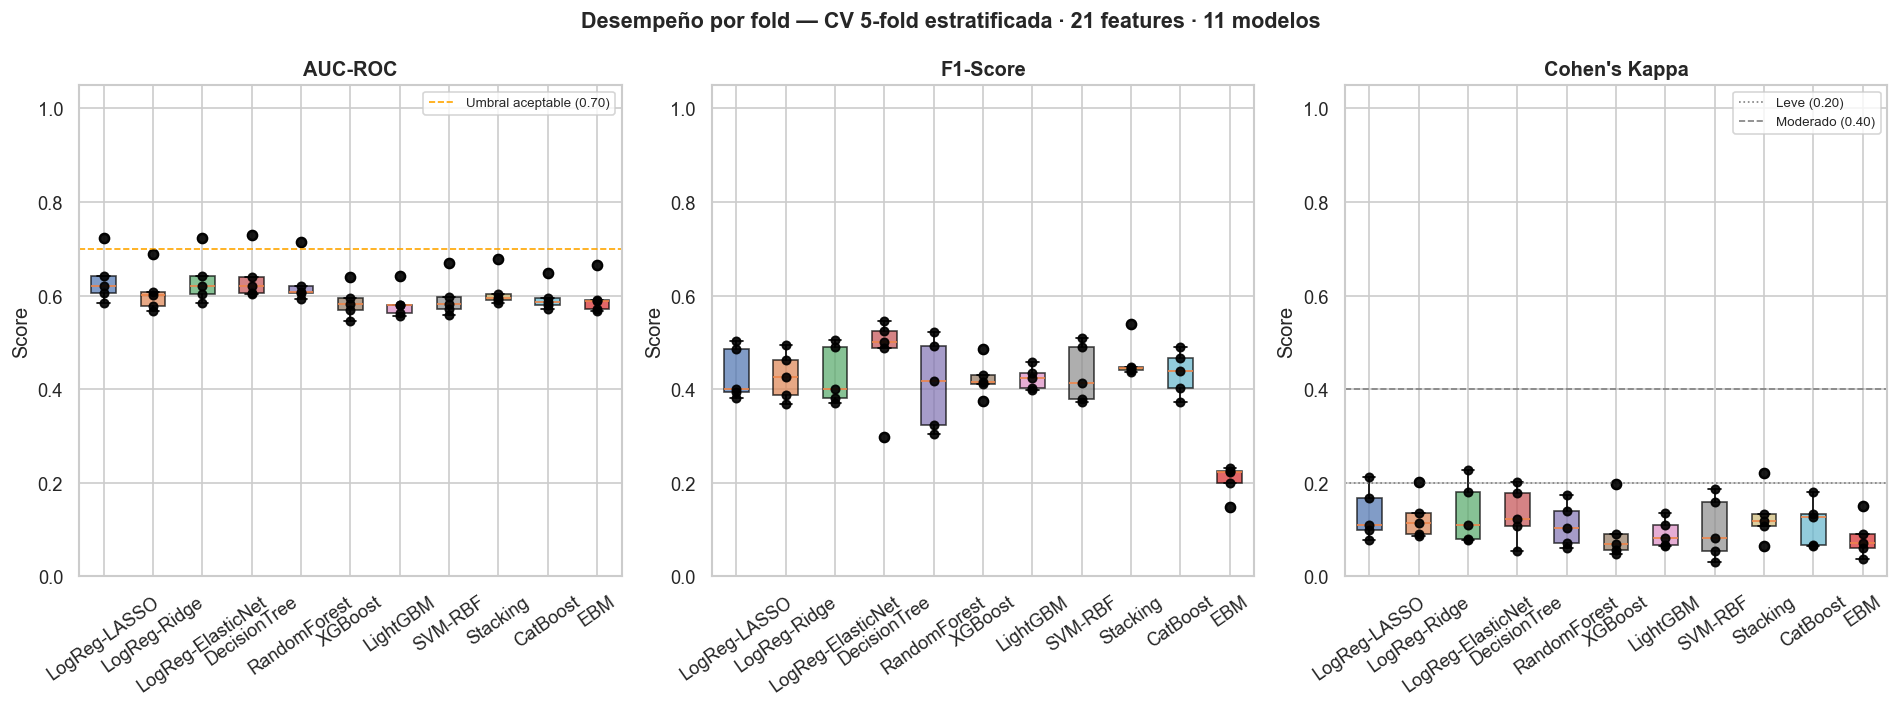

In [107]:
metric_display = [('AUC-ROC', 'test_AUC-ROC'), ('F1-Score', 'test_F1'), ("Cohen's Kappa", 'test_Kappa')]
model_names    = list(cv_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(max(16, len(model_names) * 1.4), 6))

for ax, (label, key) in zip(axes, metric_display):
    data = [cv_results[m][key] for m in model_names]
    bp = ax.boxplot(data, labels=model_names, patch_artist=True)

    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, d in enumerate(data):
        ax.scatter([i+1]*len(d), d, color='black', s=25, zorder=5, alpha=0.9)

    if label == "Cohen's Kappa":
        ax.axhline(0.20, color='gray', linestyle=':', lw=1, label='Leve (0.20)')
        ax.axhline(0.40, color='gray', linestyle='--', lw=1, label='Moderado (0.40)')
        ax.legend(fontsize=8)

    if label == 'AUC-ROC':
        ax.axhline(0.70, color='orange', linestyle='--', lw=1, label='Umbral aceptable (0.70)')
        ax.legend(fontsize=8)

    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=35)

fig.suptitle(f'Desempeño por fold — CV 5-fold estratificada · {len(FEATURES)} features · {len(model_names)} modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Curvas ROC — todos los modelos

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, model), color in zip(models.items(), palette):
    probas = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X, y):
        m = copy.deepcopy(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        probas[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y, probas)
    auc = roc_auc_score(y, probas)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1], [0,1], 'k--', lw=1, label='Azar')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curvas ROC — predicciones out-of-fold', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 9. Curvas Precisión-Recall

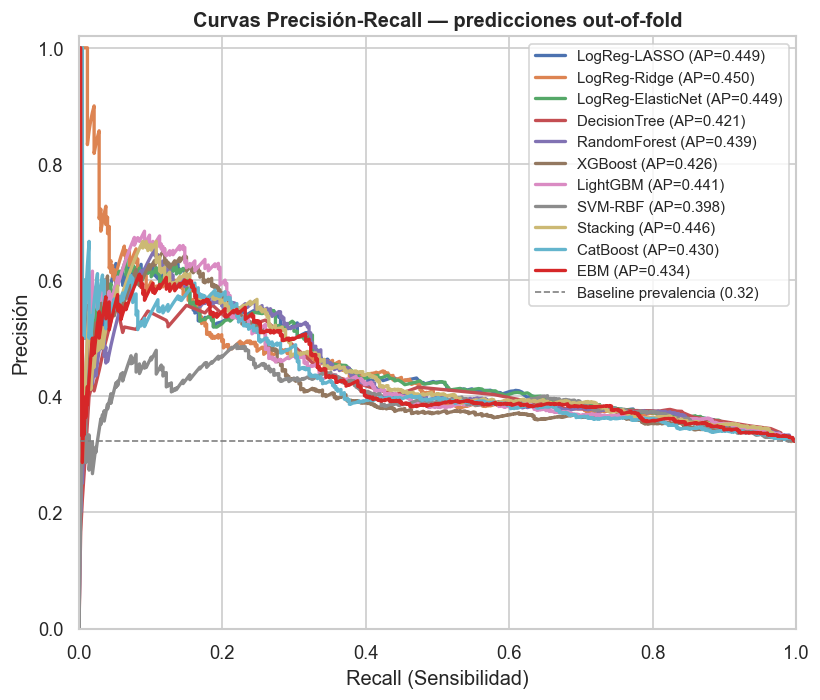

In [73]:
# Reutilizar las probabilidades calculadas en la celda anterior
# (si necesitas independencia entre celdas, vuelve a calcularlas aquí)

fig, ax = plt.subplots(figsize=(7, 6))

for (name, model), color in zip(models.items(), palette):
    probas = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X, y):
        m = copy.deepcopy(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        probas[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

    prec, rec, _ = precision_recall_curve(y, probas)
    ap = average_precision_score(y, probas)
    ax.plot(rec, prec, lw=2, color=color, label=f'{name} (AP={ap:.3f})')

ax.axhline(y.mean(), color='gray', linestyle='--', lw=1,
           label=f'Baseline prevalencia ({y.mean():.2f})')
ax.set_xlabel('Recall (Sensibilidad)')
ax.set_ylabel('Precisión')
ax.set_title('Curvas Precisión-Recall — predicciones out-of-fold', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 10. Matrices de confusión — predicciones out-of-fold

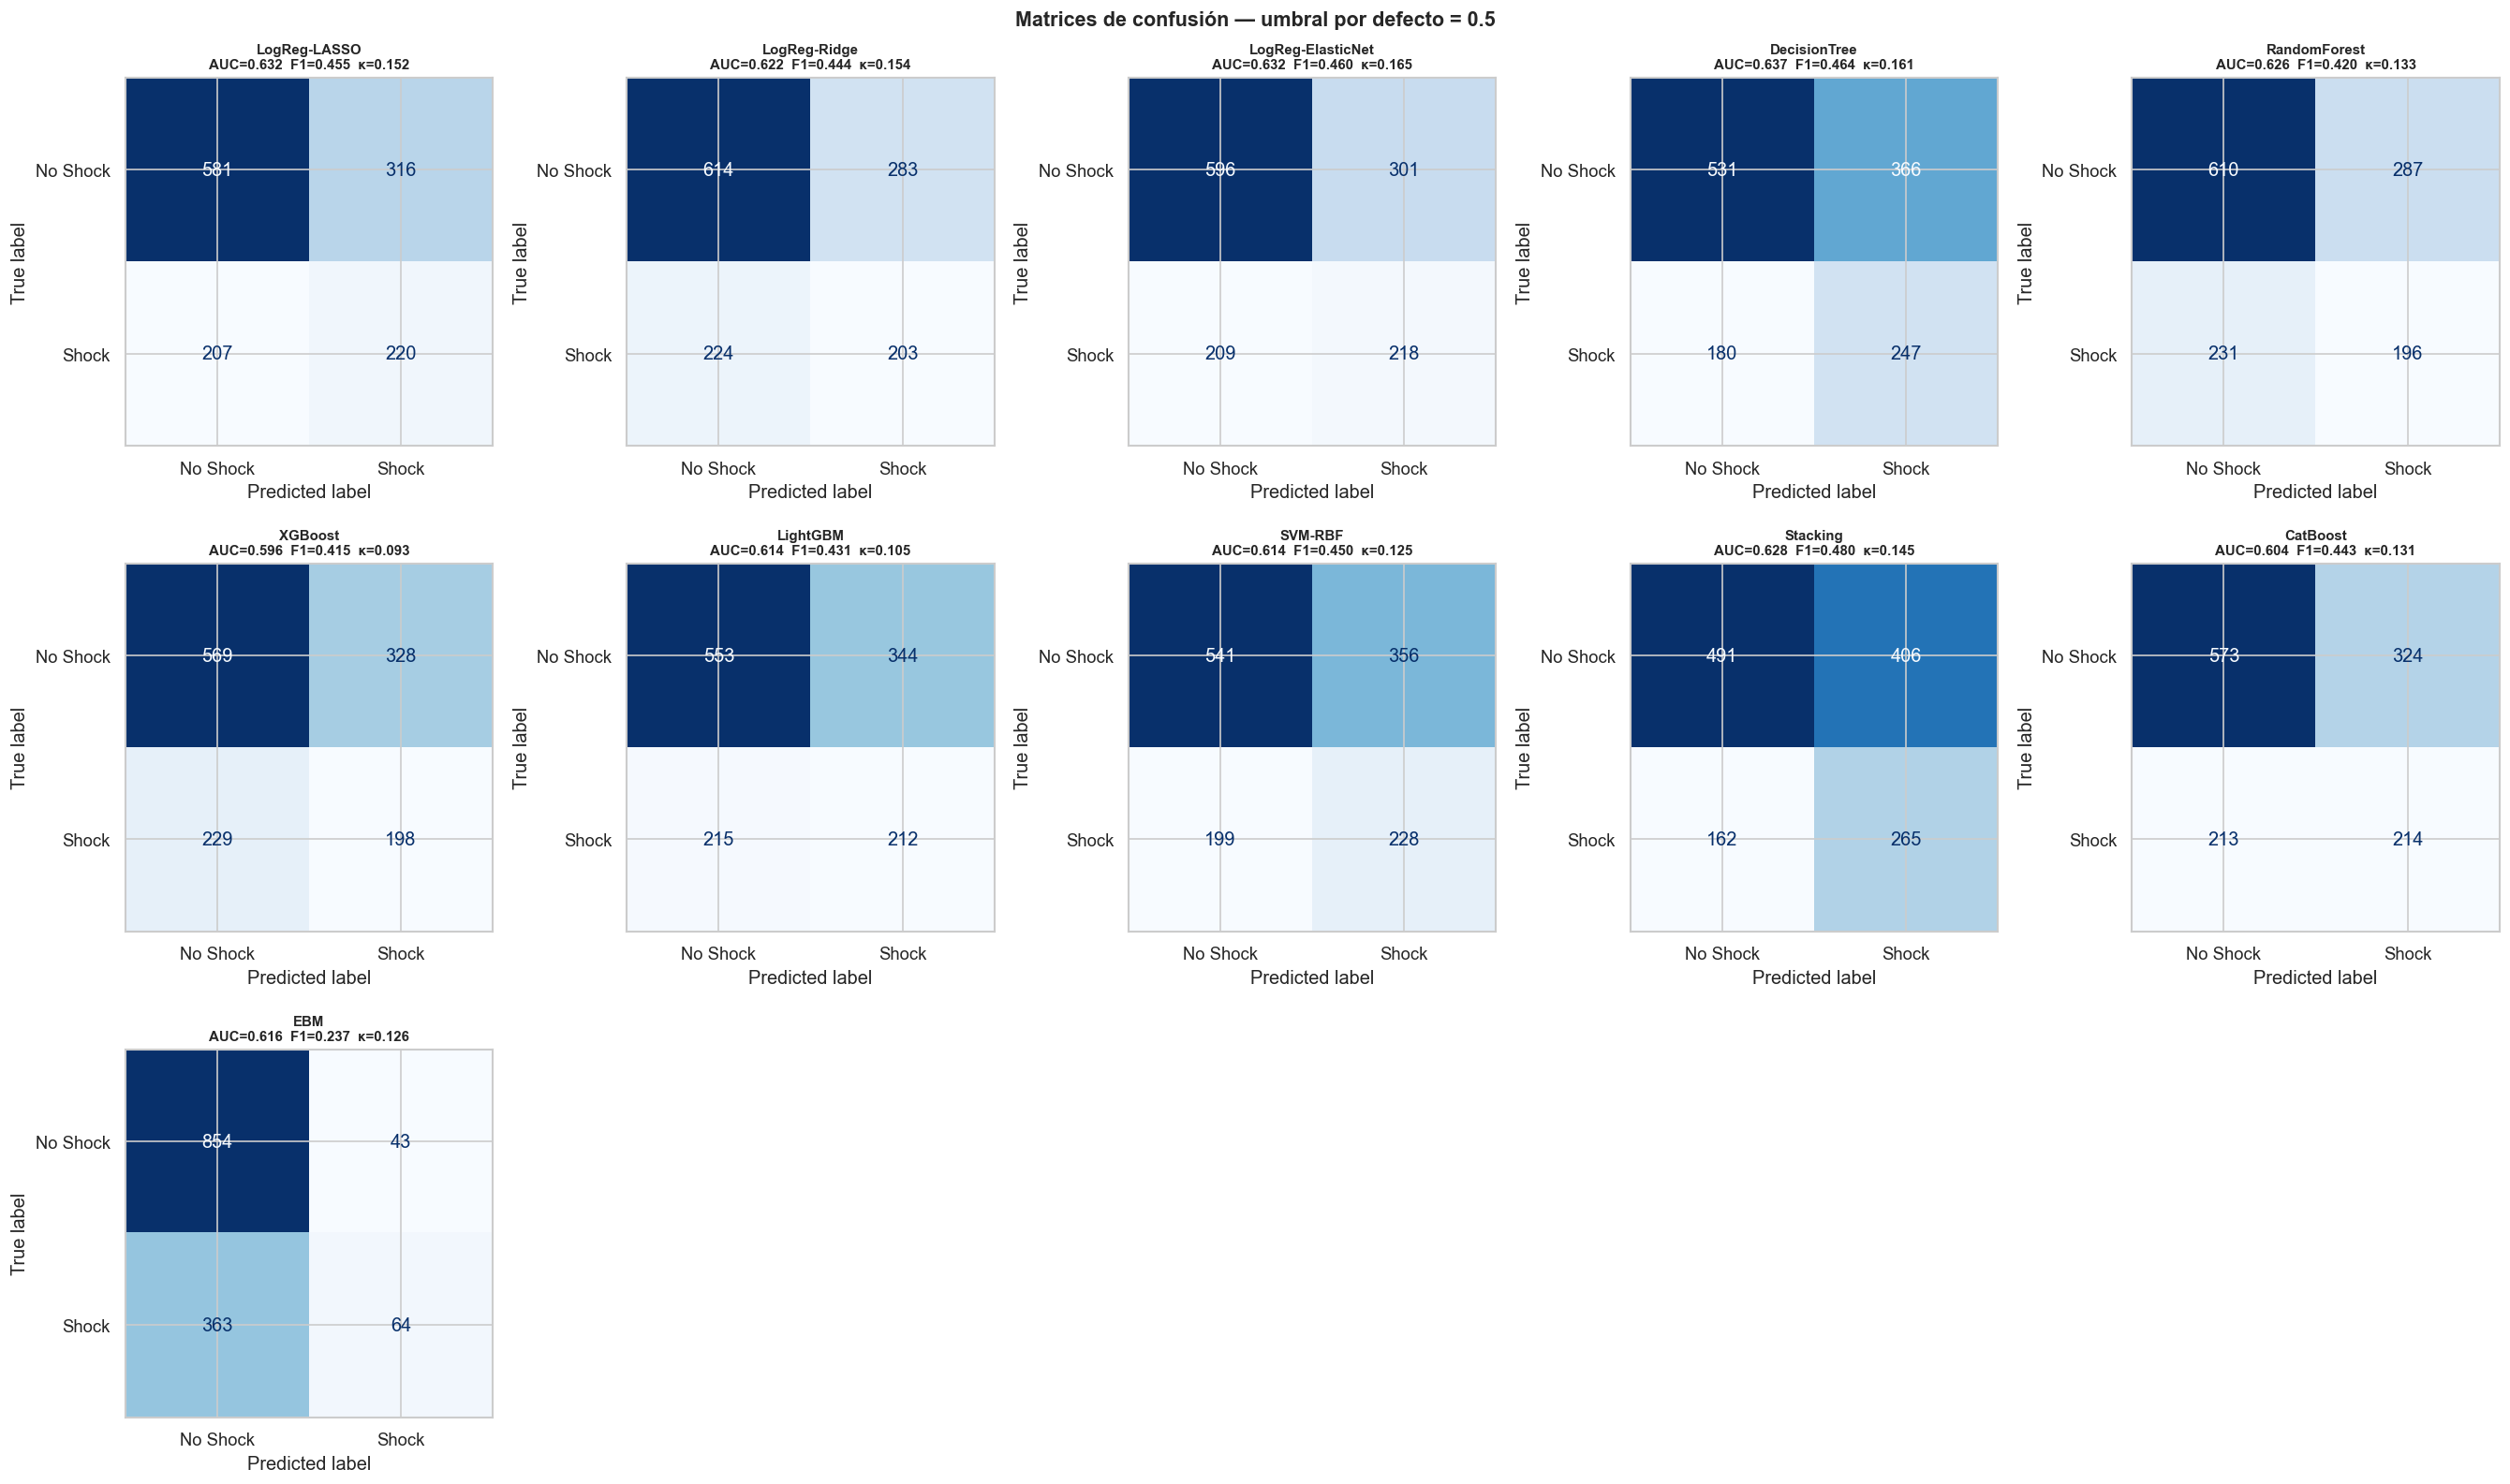

In [74]:
n_models = len(models)
n_cols   = min(5, n_models)
n_rows   = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.5))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = np.zeros(len(y), dtype=int)
    for train_idx, test_idx in cv.split(X, y):
        m = copy.deepcopy(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred[test_idx] = m.predict(X.iloc[test_idx])

    cm    = confusion_matrix(y, y_pred)
    auc   = cv_results[name]['test_AUC-ROC'].mean()
    f1v   = cv_results[name]['test_F1'].mean()
    kappa = cv_results[name]['test_Kappa'].mean()

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Shock', 'Shock'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={auc:.3f}  F1={f1v:.3f}  κ={kappa:.3f}',
                 fontweight='bold', fontsize=9)

for ax in axes[n_models:]:
    ax.set_visible(False)

fig.suptitle('Matrices de confusión — umbral por defecto = 0.5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Reporte detallado — mejor modelo

In [90]:
print(f'── Reporte detallado: {best_name} ──\n')

y_pred_best = np.zeros(len(y), dtype=int)
y_prob_best = np.zeros(len(y))

best_model_def = models[best_name]
for train_idx, test_idx in cv.split(X, y):
    m = copy.deepcopy(best_model_def)
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_best[test_idx] = m.predict(X.iloc[test_idx])
    y_prob_best[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

print(classification_report(y, y_pred_best, target_names=['No Shock', 'Shock']))
print(f"AUC-ROC       : {roc_auc_score(y, y_prob_best):.4f}")
print(f"Cohen's Kappa : {cohen_kappa_score(y, y_pred_best):.4f}")
print(f"F1-Score      : {f1_score(y, y_pred_best):.4f}")

── Reporte detallado: DecisionTree ──

              precision    recall  f1-score   support

    No Shock       0.76      0.48      0.59       807
       Shock       0.38      0.68      0.49       384

    accuracy                           0.54      1191
   macro avg       0.57      0.58      0.54      1191
weighted avg       0.64      0.54      0.56      1191

AUC-ROC       : 0.6330
Cohen's Kappa : 0.1335
F1-Score      : 0.4906


## 12. Análisis de umbral de decisión

En shock hemorrágico, **la sensibilidad es prioritaria**: es preferible una falsa alarma (FP) a un caso no detectado (FN). El umbral de 0.5 puede no ser óptimo clínicamente.

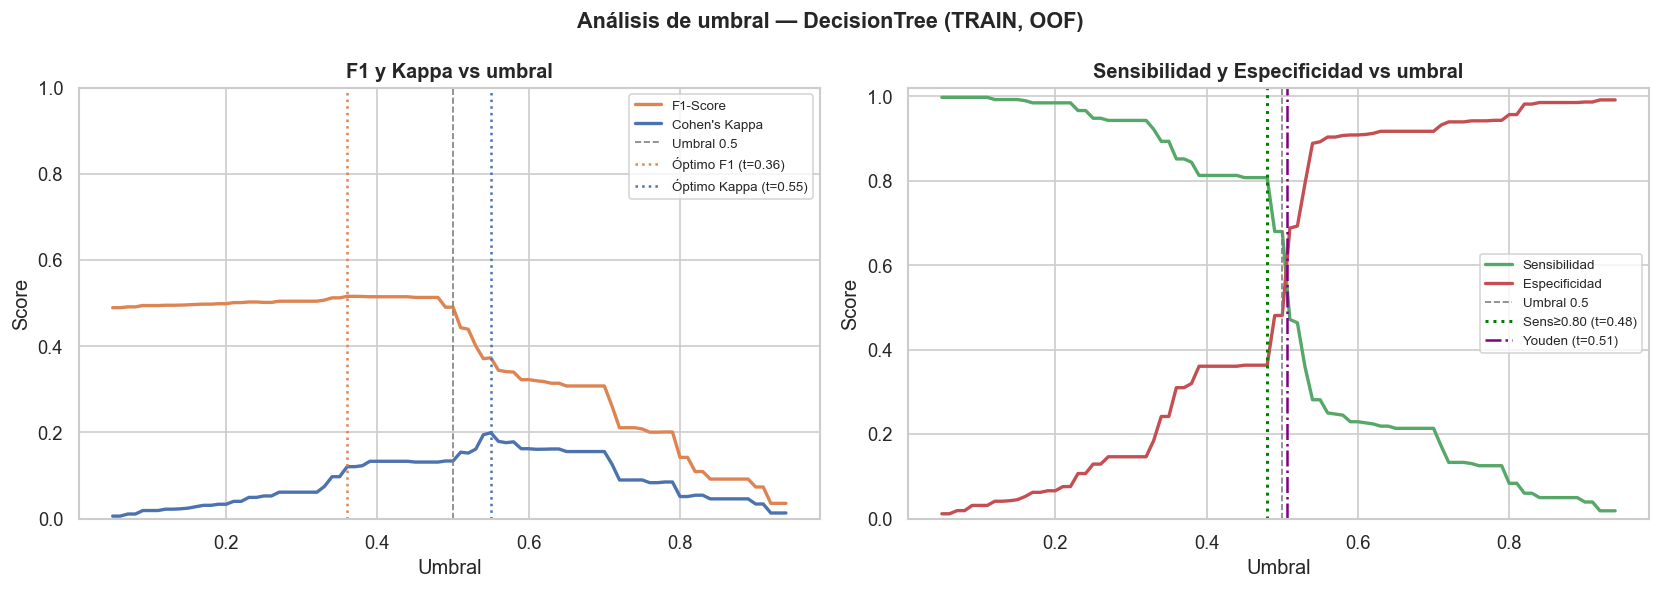

Umbral óptimo F1    : 0.36 → F1=0.5158
Umbral óptimo Kappa : 0.55 → κ=0.1991
Umbral Youden       : 0.51 → Sensibilidad=0.5781, Especificidad=0.6047
Umbral sens≥0.80    : 0.48 → Sens=0.8073, Esp=0.3631  (max Esp)

Umbral operativo seleccionado: 0.48  (prioridad: Sens≥0.80; si no existe, Youden)


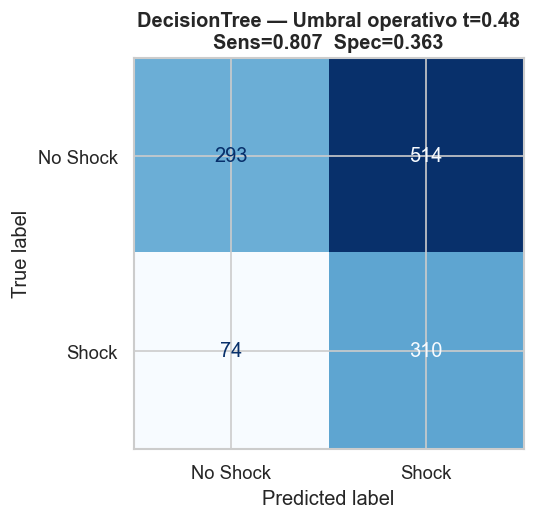


Reporte con umbral operativo (TRAIN, OOF):
              precision    recall  f1-score   support

    No Shock       0.80      0.36      0.50       807
       Shock       0.38      0.81      0.51       384

    accuracy                           0.51      1191
   macro avg       0.59      0.59      0.51      1191
weighted avg       0.66      0.51      0.50      1191



In [98]:
thresholds    = np.arange(0.05, 0.95, 0.01)
f1s           = []
kappas        = []
sensitivities = []
specificities = []

for t in thresholds:
    y_t  = (y_prob_best >= t).astype(int)
    cm   = confusion_matrix(y, y_t)
    tn, fp, fn, tp = cm.ravel()
    f1s.append(f1_score(y, y_t, zero_division=0))
    kappas.append(cohen_kappa_score(y, y_t) if y_t.sum() > 0 and y_t.sum() < len(y_t) else 0)
    sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

best_f1_thresh    = thresholds[np.argmax(f1s)]
best_kappa_thresh = thresholds[np.argmax(kappas)]

# Índice de Youden: maximiza (sensibilidad + especificidad - 1)
fpr_r, tpr_r, thresh_r = roc_curve(y, y_prob_best)
youden_idx    = np.argmax(tpr_r - fpr_r)
youden_thresh = float(thresh_r[youden_idx])
youden_sens   = float(tpr_r[youden_idx])
youden_spec   = float(1 - fpr_r[youden_idx])

# Umbral clínico sugerido: Sensibilidad >= 0.80 (en TRAIN, usando OOF)
# Elegimos el umbral que maximiza especificidad sujeto a sens>=0.80 (evita t demasiado bajo).
eligible = [i for i, s in enumerate(sensitivities) if s >= 0.80]
if eligible:
    best_i = max(eligible, key=lambda i: (specificities[i], thresholds[i]))
    sens80_thresh = float(thresholds[best_i])
    sens80_sens   = float(sensitivities[best_i])
    sens80_spec   = float(specificities[best_i])
else:
    sens80_thresh = None
    sens80_sens   = None
    sens80_spec   = None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 y Kappa
axes[0].plot(thresholds, f1s,    lw=2, color='#DD8452', label='F1-Score')
axes[0].plot(thresholds, kappas, lw=2, color='#4C72B0', label="Cohen's Kappa")
axes[0].axvline(0.5,              color='gray',    linestyle='--', lw=1,   label='Umbral 0.5')
axes[0].axvline(best_f1_thresh,   color='#DD8452', linestyle=':',  lw=1.5,
                label=f'Óptimo F1 (t={best_f1_thresh:.2f})')
axes[0].axvline(best_kappa_thresh,color='#4C72B0', linestyle=':',  lw=1.5,
                label=f'Óptimo Kappa (t={best_kappa_thresh:.2f})')
axes[0].set_xlabel('Umbral'); axes[0].set_ylabel('Score')
axes[0].set_title('F1 y Kappa vs umbral', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_ylim(0, 1)

# Sensibilidad y Especificidad
axes[1].plot(thresholds, sensitivities, lw=2, color='#55A868', label='Sensibilidad')
axes[1].plot(thresholds, specificities, lw=2, color='#C44E52', label='Especificidad')
axes[1].axvline(0.5, color='gray', linestyle='--', lw=1, label='Umbral 0.5')

if sens80_thresh is not None:
    axes[1].axvline(sens80_thresh, color='green', linestyle=':', lw=1.8,
                    label=f'Sens≥0.80 (t={sens80_thresh:.2f})')
axes[1].axvline(youden_thresh, color='purple', linestyle='-.', lw=1.5,
                label=f'Youden (t={youden_thresh:.2f})')
axes[1].set_xlabel('Umbral'); axes[1].set_ylabel('Score')
axes[1].set_title('Sensibilidad y Especificidad vs umbral', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].set_ylim(0, 1.02)

fig.suptitle(f'Análisis de umbral — {best_name} (TRAIN, OOF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Umbral óptimo F1    : {best_f1_thresh:.2f} → F1={max(f1s):.4f}')
print(f'Umbral óptimo Kappa : {best_kappa_thresh:.2f} → κ={max(kappas):.4f}')
print(f'Umbral Youden       : {youden_thresh:.2f} → Sensibilidad={youden_sens:.4f}, Especificidad={youden_spec:.4f}')
if sens80_thresh is not None:
    print(f'Umbral sens≥0.80    : {sens80_thresh:.2f} → Sens={sens80_sens:.4f}, Esp={sens80_spec:.4f}  (max Esp)')
else:
    print('Umbral sens≥0.80    : no existe en la grilla (0.05–0.94)')

# ── Umbral operativo: prioridad clínica Sens≥0.80 ───────────────────────────
THRESH_YOUDEN  = youden_thresh
THRESH_SENS80  = sens80_thresh
OPERATING_THRESHOLD = sens80_thresh if sens80_thresh is not None else youden_thresh
print(f'\nUmbral operativo seleccionado: {OPERATING_THRESHOLD:.2f}  (prioridad: Sens≥0.80; si no existe, Youden)')

y_pred_best = (y_prob_best >= OPERATING_THRESHOLD).astype(int)
cm = confusion_matrix(y, y_pred_best)
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn) if (tp + fn) else 0.0
spec = tn / (tn + fp) if (tn + fp) else 0.0

fig, ax = plt.subplots(figsize=(5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Shock', 'Shock'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'{best_name} — Umbral operativo t={OPERATING_THRESHOLD:.2f}\nSens={sens:.3f}  Spec={spec:.3f}',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('\nReporte con umbral operativo (TRAIN, OOF):')
print(classification_report(y, y_pred_best, target_names=['No Shock', 'Shock']))

## 13. Calibración y Test de Hosmer-Lemeshow

Evalúa si las probabilidades predichas corresponden a frecuencias observadas. Requerido por TRIPOD si el modelo reporta probabilidades absolutas.

**Test de Hosmer-Lemeshow:** p > 0.05 indica calibración aceptable (no hay evidencia de desajuste). Un modelo con AUC alto pero calibración pobre sobreestima o subestima el riesgo absoluto, lo que es clínicamente peligroso.

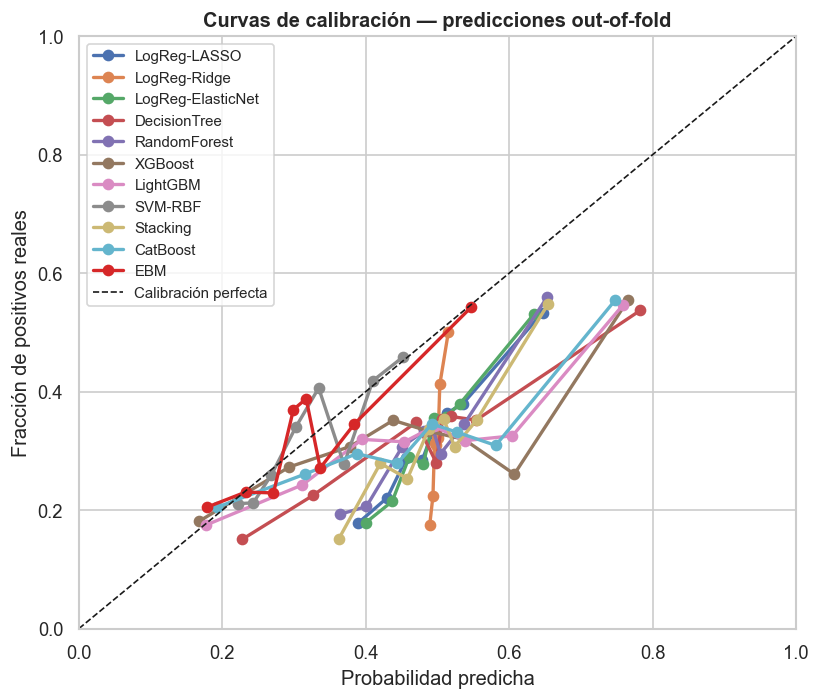


── Test de Hosmer-Lemeshow (g=10 deciles) ──
  Modelo                   H   p-valor  Interpretación
  -------------------------------------------------------
  LogReg-LASSO       170.644    0.0000  mal calibrado   ✗
  LogReg-Ridge       213.050    0.0000  mal calibrado   ✗
  LogReg-ElasticNet  173.563    0.0000  mal calibrado   ✗
  DecisionTree       172.018    0.0000  mal calibrado   ✗
  RandomForest       159.409    0.0000  mal calibrado   ✗
  XGBoost            181.732    0.0000  mal calibrado   ✗
  LightGBM           168.593    0.0000  mal calibrado   ✗
  SVM-RBF              9.223    0.3238  bien calibrado  ✓
  Stacking           176.773    0.0000  mal calibrado   ✗
  CatBoost           161.357    0.0000  mal calibrado   ✗
  EBM                 15.879    0.0441  mal calibrado   ✗

  (H: estadístico chi2; p > 0.05 indica calibración aceptable)


In [77]:
def hosmer_lemeshow(y_true, y_prob, g=10):
    """Test de Hosmer-Lemeshow. p > 0.05 → calibración aceptable."""
    df_hl = pd.DataFrame({'y': y_true.astype(int), 'p': y_prob})
    df_hl['decile'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    grp = df_hl.groupby('decile', observed=True).agg(
        obs=('y', 'sum'), exp=('p', 'sum'), n=('y', 'count')
    )
    hl = (((grp['obs'] - grp['exp'])**2) /
          (grp['exp'] * (1 - grp['exp'] / grp['n']))).sum()
    p = 1 - chi2_dist.cdf(hl, df=len(grp) - 2)
    return hl, p

# ── Curvas de calibración ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

# Reutilizar oof_probs si están disponibles, o recalcular
try:
    _calib_probs = oof_probs
except NameError:
    _calib_probs = {}
    for name, model in models.items():
        probs = np.zeros(len(y))
        for train_idx, test_idx in cv.split(X, y):
            m = copy.deepcopy(model)
            m.fit(X.iloc[train_idx], y.iloc[train_idx])
            probs[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]
        _calib_probs[name] = probs

for (name, _), color in zip(models.items(), palette):
    prob_true, prob_pred = calibration_curve(
        y, _calib_probs[name], n_bins=8, strategy='quantile'
    )
    ax.plot(prob_pred, prob_true, marker='o', lw=2, color=color, label=name)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Calibración perfecta')
ax.set_xlabel('Probabilidad predicha')
ax.set_ylabel('Fracción de positivos reales')
ax.set_title('Curvas de calibración — predicciones out-of-fold', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

# ── Hosmer-Lemeshow (todos los modelos) ─────────────────────────────────────
print('\n── Test de Hosmer-Lemeshow (g=10 deciles) ──')
print(f'  {"Modelo":<18} {"H":>7}  {"p-valor":>8}  Interpretación')
print('  ' + '-'*55)
for name in models:
    hl_stat, hl_p = hosmer_lemeshow(y.values, _calib_probs[name])
    interp = 'bien calibrado  ✓' if hl_p > 0.05 else 'mal calibrado   ✗'
    print(f'  {name:<18} {hl_stat:>7.3f}  {hl_p:>8.4f}  {interp}')
print('\n  (H: estadístico chi2; p > 0.05 indica calibración aceptable)')

# Calibración post-hoc con Platt Scaling

Entrenando modelos calibrados con Platt scaling (sigmoid)...
  LogReg-LASSO listo.
  LogReg-Ridge listo.
  LogReg-ElasticNet listo.
  DecisionTree listo.
  RandomForest listo.
  XGBoost listo.
  LightGBM listo.
  SVM-RBF listo.
  Stacking listo.
  CatBoost listo.
  EBM listo.


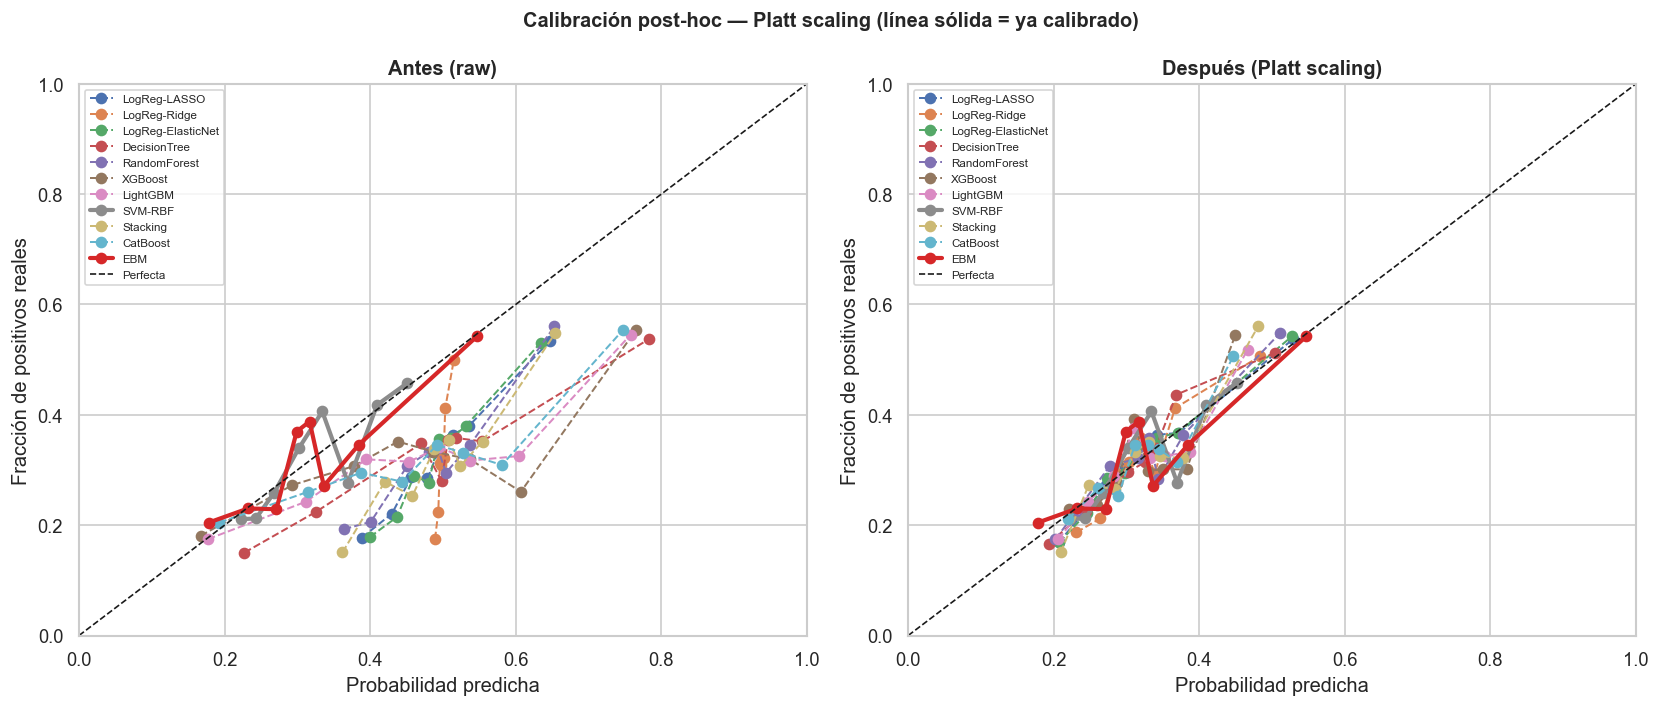


── Hosmer-Lemeshow tras Platt scaling ──
  Modelo               H antes  H después  p después  Resultado
  -----------------------------------------------------------------
  LogReg-LASSO          170.64     12.919     0.1147  ✓  ↓ mejoró
  LogReg-Ridge          213.05     12.864     0.1166  ✓  ↓ mejoró
  LogReg-ElasticNet     173.56     13.201     0.1051  ✓  ↓ mejoró
  DecisionTree          172.02     17.845     0.0224  ✗  ↓ mejoró
  RandomForest          159.41     13.414     0.0984  ✓  ↓ mejoró
  XGBoost               181.73     27.886     0.0005  ✗  ↓ mejoró
  LightGBM              168.59     12.968     0.1129  ✓  ↓ mejoró
  SVM-RBF                 9.22      9.223     0.3238  ✓  ~ similar
  Stacking              176.77      8.132     0.4207  ✓  ↓ mejoró
  CatBoost              161.36     10.411     0.2373  ✓  ↓ mejoró
  EBM                    15.88     15.879     0.0441  ✗  ~ similar

  Modelos recomendados para reporte de probabilidades absolutas:
    → LogReg-LASSO
    → LogReg-

In [78]:
# ── Sección 13.2: Calibración post-hoc con Platt scaling ────────────────────
#
# Resultado previo: solo SVM-RBF y EBM pasan el test de Hosmer-Lemeshow.
# Los demás tienen probabilidades comprimidas (rango ~0.2-0.8) → se aplica
# CalibratedClassifierCV(method='sigmoid') para corregirlo.
#
# Los modelos BIEN calibrados (SVM-RBF, EBM) se usan tal cual.

_WELL_CALIBRATED = {'SVM-RBF', 'EBM'}

print('Entrenando modelos calibrados con Platt scaling (sigmoid)...')
calibrated_models = {}
oof_probs_cal     = {}

for name, model in models.items():
    if name in _WELL_CALIBRATED:
        cal_model = copy.deepcopy(model)
    else:
        cal_model = CalibratedClassifierCV(
            copy.deepcopy(model), method='sigmoid', cv=5
        )

    probs = np.zeros(len(y))
    for train_idx, test_idx in cv.split(X, y):
        m = copy.deepcopy(cal_model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        probs[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

    calibrated_models[name] = cal_model
    oof_probs_cal[name]     = probs
    print(f'  {name} listo.')

# Comparación de curvas de calibración: antes vs después
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (probs_dict, title) in zip(axes, [
    (_calib_probs if '_calib_probs' in dir() else oof_probs,  'Antes (raw)'),
    (oof_probs_cal,                                            'Después (Platt scaling)'),
]):
    for (name, _), color in zip(models.items(), palette):
        if name not in probs_dict:
            continue
        pt, pp = calibration_curve(y, probs_dict[name], n_bins=8, strategy='quantile')
        lw = 2.5 if name in _WELL_CALIBRATED else 1.2
        ls = '-'  if name in _WELL_CALIBRATED else '--'
        ax.plot(pp, pt, marker='o', lw=lw, ls=ls, color=color, label=name)

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfecta')
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Fracción de positivos reales')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle('Calibración post-hoc — Platt scaling (línea sólida = ya calibrado)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# HL test después de calibración
print('\n── Hosmer-Lemeshow tras Platt scaling ──')
print(f'  {"Modelo":<18} {"H antes":>9}  {"H después":>9}  {"p después":>9}  Resultado')
print('  ' + '-'*65)
for name in models:
    if name not in oof_probs_cal:
        continue
    # HL "antes" viene del _calib_probs ya calculado en sección 13
    _before = _calib_probs.get(name, oof_probs.get(name, oof_probs_cal[name]))
    h_before, _ = hosmer_lemeshow(y.values, _before)
    h_after,  p = hosmer_lemeshow(y.values, oof_probs_cal[name])
    marker = '✓' if p > 0.05 else '✗'
    mejora = '↓ mejoró' if h_after < h_before * 0.5 else '~ similar'
    print(f'  {name:<18} {h_before:>9.2f}  {h_after:>9.3f}  {p:>9.4f}  {marker}  {mejora}')

print('\n  Modelos recomendados para reporte de probabilidades absolutas:')
for name in models:
    if name not in oof_probs_cal:
        continue
    _, p = hosmer_lemeshow(y.values, oof_probs_cal[name])
    if p > 0.05:
        print(f'    → {name}')

## 13.3. Diagnóstico post-calibración (sin re-entrenar)

Este bloque mantiene el orden del pipeline: **solo evalúa** qué cambió con Platt scaling usando predicciones out-of-fold ya calculadas.

- `AUC-ROC`: discriminación (no suele mejorar con calibración).
- `Brier`, `Log-loss`, `ECE`: calibración (aquí sí suele mejorar).

In [79]:
# Métricas donde la calibración SÍ importa (y AUC donde suele NO cambiar mucho)
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
import numpy as np
import pandas as pd

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """ECE (Expected Calibration Error) usando bins por cuantiles."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_prob, qs)
    edges[0], edges[-1] = -1e-9, 1 + 1e-9
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (y_prob > lo) & (y_prob <= hi)
        if not mask.any():
            continue
        frac_pos = y_true[mask].mean()
        mean_p   = y_prob[mask].mean()
        ece += mask.mean() * abs(frac_pos - mean_p)
    return float(ece)

raw_probs = _calib_probs if '_calib_probs' in globals() else oof_probs
cal_probs = oof_probs_cal if 'oof_probs_cal' in globals() else None

rows = []
for name in models:
    if name not in raw_probs:
        continue
    p_raw = np.clip(raw_probs[name], 1e-6, 1-1e-6)
    row = {
        'Modelo': name,
        'AUC (raw)': roc_auc_score(y, p_raw),
        'Brier (raw)': brier_score_loss(y, p_raw),
        'LogLoss (raw)': log_loss(y, p_raw),
        'ECE (raw)': expected_calibration_error(y, p_raw, n_bins=10),
    }
    if cal_probs is not None and name in cal_probs:
        p_cal = np.clip(cal_probs[name], 1e-6, 1-1e-6)
        row.update({
            'AUC (Platt)': roc_auc_score(y, p_cal),
            'Brier (Platt)': brier_score_loss(y, p_cal),
            'LogLoss (Platt)': log_loss(y, p_cal),
            'ECE (Platt)': expected_calibration_error(y, p_cal, n_bins=10),
        })
        row['ΔAUC'] = row['AUC (Platt)'] - row['AUC (raw)']
        row['ΔBrier'] = row['Brier (Platt)'] - row['Brier (raw)']
        row['ΔLogLoss'] = row['LogLoss (Platt)'] - row['LogLoss (raw)']
        row['ΔECE'] = row['ECE (Platt)'] - row['ECE (raw)']
    rows.append(row)

metrics_df = pd.DataFrame(rows)
if cal_probs is not None:
    metrics_df = metrics_df.sort_values(['Brier (Platt)', 'ECE (Platt)'], ascending=True)
else:
    metrics_df = metrics_df.sort_values(['Brier (raw)', 'ECE (raw)'], ascending=True)

display(metrics_df.reset_index(drop=True))

if cal_probs is not None and best_name in raw_probs and best_name in cal_probs:
    print('\nResumen rápido — mejor modelo')
    print(f"  {best_name}: AUC raw={roc_auc_score(y, raw_probs[best_name]):.4f} | AUC Platt={roc_auc_score(y, cal_probs[best_name]):.4f}")
    print(f"  {best_name}: Brier raw={brier_score_loss(y, raw_probs[best_name]):.4f} | Brier Platt={brier_score_loss(y, cal_probs[best_name]):.4f}")

,Modelo,AUC (raw),Brier (raw),LogLoss (raw),ECE (raw),AUC (Platt),Brier (Platt),LogLoss (Platt),ECE (Platt),ΔAUC,ΔBrier,ΔLogLoss,ΔECE
0,LogReg-ElasticNet,0.631482,0.237692,0.668549,0.170772,0.632072,0.207477,0.603950,0.038462,0.000590,-0.030215,-0.064599,-0.132310
1,DecisionTree,0.624973,0.235610,0.686305,0.156719,0.633085,0.207897,0.604224,0.034668,0.008112,-0.027713,-0.082081,-0.122051
2,LogReg-LASSO,0.631732,0.237012,0.667261,0.170179,0.630326,0.208030,0.605105,0.037992,-0.001406,-0.028982,-0.062156,-0.132187
3,RandomForest,0.621034,0.234353,0.661655,0.163108,0.619954,0.208080,0.605180,0.037228,-0.001081,-0.026272,-0.056475,-0.125880
4,Stacking,0.623758,0.238319,0.669485,0.173644,0.616771,0.209541,0.608315,0.028526,-0.006987,-0.028778,-0.061170,-0.145118
5,LogReg-Ridge,0.620285,0.248222,0.689590,0.181646,0.619314,0.209783,0.609210,0.041168,-0.000971,-0.038439,-0.080380,-0.140478
6,EBM,0.613515,0.209988,0.610326,0.041440,0.613515,0.209988,0.610326,0.041440,0.000000,0.000000,0.000000,0.000000
7,LightGBM,0.613998,0.235349,0.664349,0.143896,0.608060,0.210519,0.610520,0.040719,-0.005938,-0.024830,-0.053829,-0.103176
8,SVM-RBF,0.606709,0.212183,0.613987,0.036399,0.606709,0.212183,0.613987,0.036399,0.000000,0.000000,0.000000,0.000000
9,XGBoost,0.595123,0.239354,0.675330,0.145930,0.590759,0.212451,0.615113,0.057429,-0.004364,-0.026903,-0.060216,-0.088501



Resumen rápido — mejor modelo
  DecisionTree: AUC raw=0.6250 | AUC Platt=0.6331
  DecisionTree: Brier raw=0.2356 | Brier Platt=0.2079


## 13.5. Decision Curve Analysis (DCA)

Evalúa el **beneficio neto clínico** del modelo en función del umbral de probabilidad que un médico consideraría para intervenir.  
Supera a AUC/F1 al responder: *¿vale la pena usar este modelo en la práctica?*

- **Tratar a todos**: beneficio neto si se interviene en todos los pacientes (sin modelo).
- **No tratar a nadie**: beneficio neto = 0.
- Si la curva del modelo supera ambas líneas de referencia → el modelo **añade valor clínico neto**.

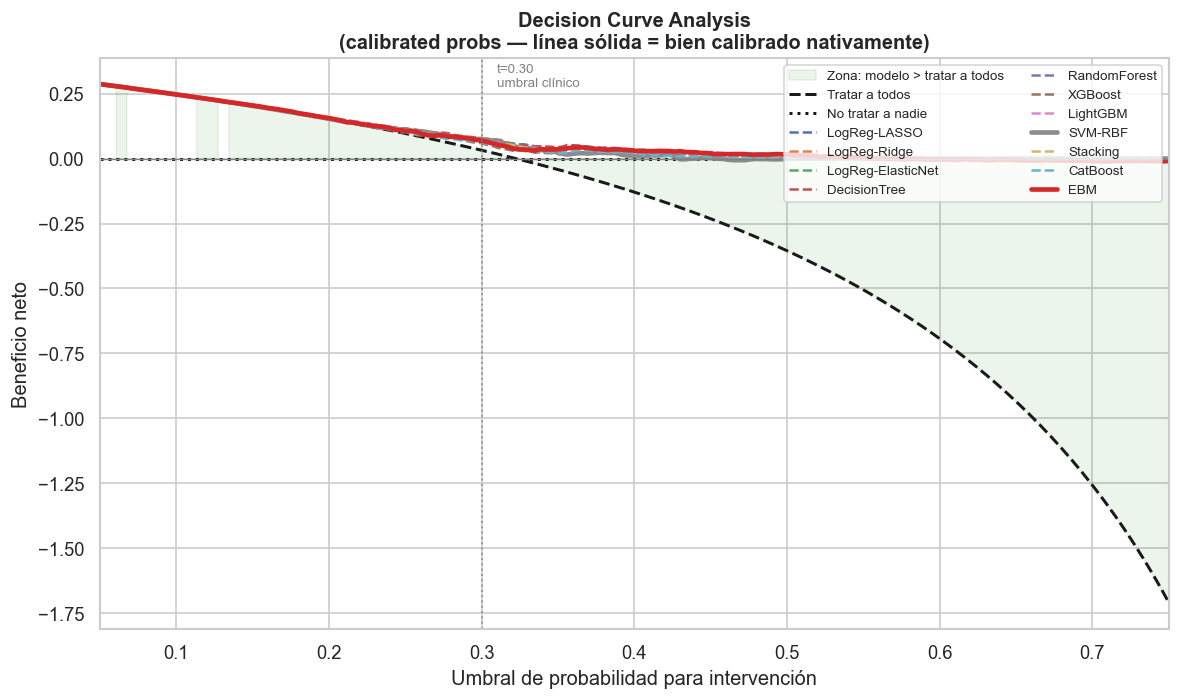


── Beneficio neto (calibradas (Platt)) a umbrales clínicos ──
  Modelo               t=0.10    t=0.20    t=0.30    t=0.40  Cal?
  --------------------------------------------------------------------
  LogReg-LASSO         0.2472    0.1562    0.0687    0.0239  ✓*
  LogReg-Ridge         0.2472    0.1522    0.0720    0.0239  ✓*
  LogReg-ElasticNet    0.2472    0.1579    0.0716    0.0257  ✓*
  DecisionTree         0.2472    0.1592    0.0781    0.0259  ✓*
  RandomForest         0.2472    0.1548    0.0667    0.0342  ✓*
  XGBoost              0.2472    0.1569    0.0596    0.0279  ✓*
  LightGBM             0.2472    0.1558    0.0666    0.0247  ✓*
  SVM-RBF              0.2472    0.1533    0.0748    0.0091  ✓
  Stacking             0.2472    0.1546    0.0694    0.0307  ✓*
  CatBoost             0.2472    0.1516    0.0625    0.0217  ✓*
  EBM                  0.2468    0.1552    0.0693    0.0305  ✓
  Tratar a todos       0.2479    0.1518    0.0325   -0.1325

  * calibrado con Platt scaling


In [80]:
def net_benefit(y_true, y_prob, threshold):
    """Beneficio neto a un umbral de probabilidad dado."""
    n = len(y_true)
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return tp / n - fp / n * (threshold / (1 - threshold))

thresholds_dca = np.linspace(0.05, 0.75, 200)

nb_treat_all  = np.array([
    y.mean() - (1 - y.mean()) * (t / (1 - t)) for t in thresholds_dca
])
nb_treat_none = np.zeros_like(thresholds_dca)

# Usar probabilidades calibradas si están disponibles
_dca_probs = oof_probs_cal if 'oof_probs_cal' in globals() else (
             oof_probs     if 'oof_probs'     in globals() else _calib_probs)

fig, ax = plt.subplots(figsize=(10, 6))

# Calcular beneficio neto por modelo
nb_curves = {}
for name in models:
    if name not in _dca_probs:
        continue
    nb_curves[name] = np.array([
        net_benefit(y.values, _dca_probs[name], t) for t in thresholds_dca
    ])

# Sombrear zona donde algún modelo supera "tratar a todos"
any_beats_all = np.zeros_like(thresholds_dca, dtype=bool)
for nb in nb_curves.values():
    any_beats_all |= (nb > nb_treat_all)

if any_beats_all.any():
    ax.fill_between(thresholds_dca, 0, nb_treat_all,
                    where=any_beats_all,
                    alpha=0.08, color='green',
                    label='Zona: modelo > tratar a todos')

# Líneas de referencia
ax.plot(thresholds_dca, nb_treat_all,  'k--',  lw=1.8, label='Tratar a todos')
ax.plot(thresholds_dca, nb_treat_none, 'k:',   lw=1.8, label='No tratar a nadie')

# Curvas por modelo — más gruesas para SVM-RBF y EBM
for (name, _), color in zip(models.items(), palette):
    if name not in nb_curves:
        continue
    lw = 2.8 if name in _WELL_CALIBRATED else 1.5
    ls = '-'  if name in _WELL_CALIBRATED else '--'
    ax.plot(thresholds_dca, nb_curves[name], lw=lw, ls=ls,
            color=color, label=name)

# Anotar umbral clínico relevante (0.30) con línea vertical
ax.axvline(0.30, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.text(0.31, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 0.01,
        't=0.30\numbral clínico',
        fontsize=8, color='gray', va='top')

ax.axhline(0, color='gray', lw=0.8)
ax.set_xlim(0.05, 0.75)
ax.set_xlabel('Umbral de probabilidad para intervención')
ax.set_ylabel('Beneficio neto')
ax.set_title('Decision Curve Analysis\n(calibrated probs — línea sólida = bien calibrado nativamente)',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

# Tabla con probabilidades calibradas
source_label = 'calibradas (Platt)' if 'oof_probs_cal' in globals() else 'raw OOF'
print(f'\n── Beneficio neto ({source_label}) a umbrales clínicos ──')
print(f'  {"Modelo":<18} {"t=0.10":>8}  {"t=0.20":>8}  {"t=0.30":>8}  {"t=0.40":>8}  Cal?')
print('  ' + '-'*68)
for name in models:
    if name not in nb_curves:
        continue
    nbs   = [f'{net_benefit(y.values, _dca_probs[name], t):>8.4f}' for t in [0.10, 0.20, 0.30, 0.40]]
    cal_m = '✓' if name in _WELL_CALIBRATED else ('✓*' if 'oof_probs_cal' in globals() else '✗')
    print(f'  {name:<18} {"  ".join(nbs)}  {cal_m}')
ref  = [f'{nb_treat_all[np.argmin(np.abs(thresholds_dca - t))]:>8.4f}' for t in [0.10, 0.20, 0.30, 0.40]]
print(f'  {"Tratar a todos":<18} {"  ".join(ref)}')
print('\n  * calibrado con Platt scaling')

## 14. Interpretabilidad SHAP — modelo final

Calculando SHAP para: DecisionTree


  0%|          | 0/1324 [00:00<?, ?it/s]

Explainer: kernel  |  SHAP shape: (1324, 21, 2)


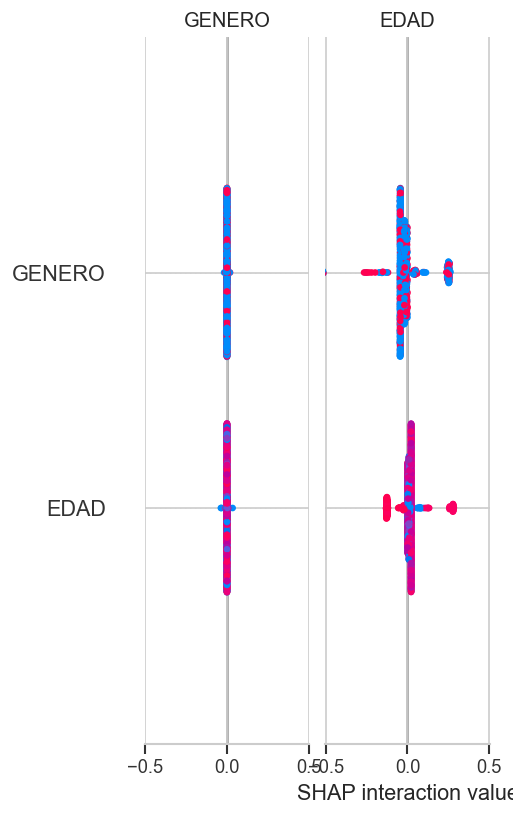

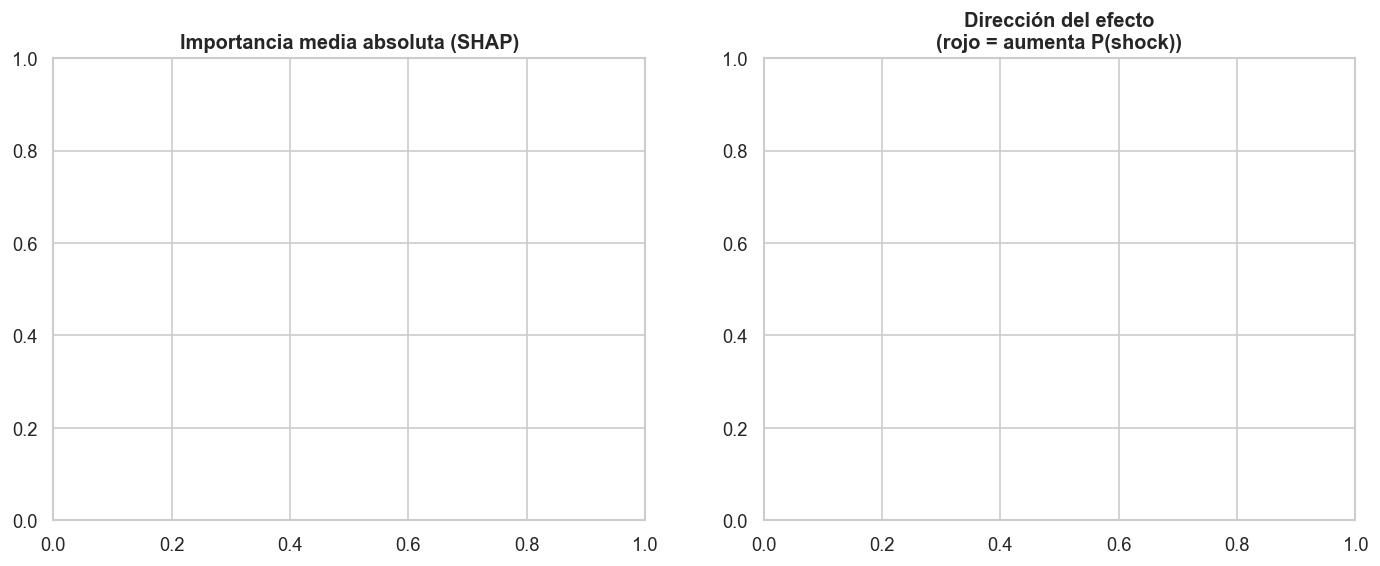

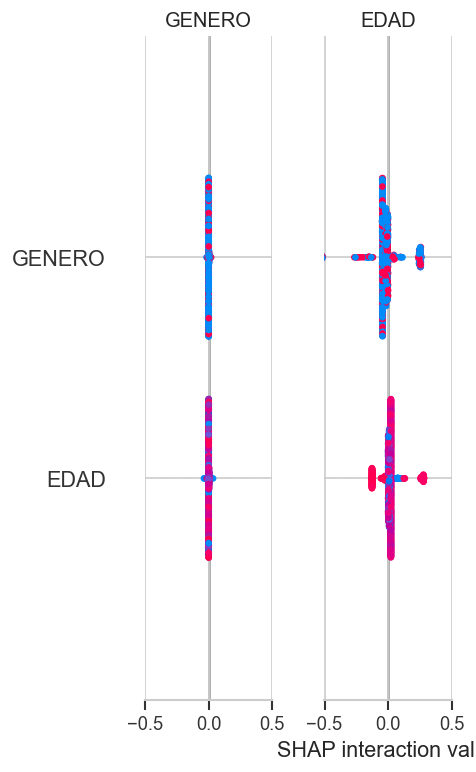

In [81]:
# Entrenar modelo final en todos los datos
final_model = copy.deepcopy(models[best_name])
final_model.fit(X, y)

# ── Detectar tipo de modelo y construir explainer apropiado ─────────────────
def _get_shap(model, X_data, name):
    """Devuelve (explainer_type, shap_values, X_display)."""

    # Pipeline: extraer clf y transformar X si hay scaler
    if hasattr(model, 'named_steps'):
        clf  = model.named_steps['clf']
        if 'scaler' in model.named_steps:
            X_tr = pd.DataFrame(
                model.named_steps['scaler'].transform(X_data),
                columns=X_data.columns
            )
        else:
            X_tr = X_data
        return _get_shap(clf, X_tr, name)

    model_type = type(model).__name__

    # Regresión logística → LinearExplainer
    if 'LogisticRegression' in model_type:
        exp  = shap.LinearExplainer(model, X_data)
        vals = exp.shap_values(X_data)
        return 'linear', vals, X_data

    # Árboles (RF, XGB, LGB, CatBoost, EBM) → TreeExplainer
    if model_type in ('RandomForestClassifier', 'XGBClassifier',
                      'LGBMClassifier', 'CatBoostClassifier',
                      'ExplainableBoostingClassifier'):
        exp = shap.TreeExplainer(model)
        sv  = exp.shap_values(X_data)
        # RF devuelve lista [clase0, clase1]
        vals = sv[1] if isinstance(sv, list) else sv
        return 'tree', vals, X_data

    # SVM y Stacking → KernelExplainer (muestreo de background para velocidad)
    bg   = shap.sample(X_data, 100, random_state=RANDOM_STATE)
    exp  = shap.KernelExplainer(model.predict_proba, bg)
    vals = exp.shap_values(X_data, nsamples=200)
    vals = vals[1] if isinstance(vals, list) else vals
    return 'kernel', vals, X_data

print(f'Calculando SHAP para: {best_name}')

# EBM tiene su propia API de interpretabilidad — complementar con SHAP
if best_name == 'EBM' and _has_ebm:
    ebm_global = final_model.explain_global()
    print('\n── EBM: Importancia de features (API nativa) ──')
    for feat, imp in sorted(
        zip(ebm_global.data()['names'], ebm_global.data()['scores']),
        key=lambda x: abs(x[1]), reverse=True
    ):
        print(f'  {feat:<20} score={imp:.4f}')
    print('\n(EBM además soporta plotly interactivo: ebm_global.visualize())')

expl_type, shap_vals, X_shap = _get_shap(final_model, X, best_name)
print(f'Explainer: {expl_type}  |  SHAP shape: {np.array(shap_vals).shape}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.summary_plot(shap_vals, X_shap, feature_names=list(FEATURES),
                  plot_type='bar', show=False)
axes[0].set_title('Importancia media absoluta (SHAP)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_vals, X_shap, feature_names=list(FEATURES),
                  plot_type='dot', show=False)
axes[1].set_title('Dirección del efecto\n(rojo = aumenta P(shock))', fontweight='bold')

plt.tight_layout()
plt.show()

── Reglas del árbol de decisión (profundidad max=4) ──

|--- HB_x_SANGRADO <= 3.35
|   |--- EDAD2 <= 2550.50
|   |   |--- EDAD2 <= 72.50
|   |   |   |--- HB_PREQX <= 13.05
|   |   |   |   |--- class: 0
|   |   |   |--- HB_PREQX >  13.05
|   |   |   |   |--- class: 0
|   |   |--- EDAD2 >  72.50
|   |   |   |--- HB_PREQX <= 12.65
|   |   |   |   |--- class: 0
|   |   |   |--- HB_PREQX >  12.65
|   |   |   |   |--- class: 0
|   |--- EDAD2 >  2550.50
|   |   |--- EDAD <= 77.50
|   |   |   |--- EDAD <= 75.50
|   |   |   |   |--- class: 1
|   |   |   |--- EDAD >  75.50
|   |   |   |   |--- class: 0
|   |   |--- EDAD >  77.50
|   |   |   |--- HB_PREQX <= 14.15
|   |   |   |   |--- class: 1
|   |   |   |--- HB_PREQX >  14.15
|   |   |   |   |--- class: 0
|--- HB_x_SANGRADO >  3.35
|   |--- EDAD2 <= 930.50
|   |   |--- EDAD <= 14.50
|   |   |   |--- class: 1
|   |   |--- EDAD >  14.50
|   |   |   |--- class: 1
|   |--- EDAD2 >  930.50
|   |   |--- EDAD2 <= 3660.50
|   |   |   |--- HB_x_SANGRADO

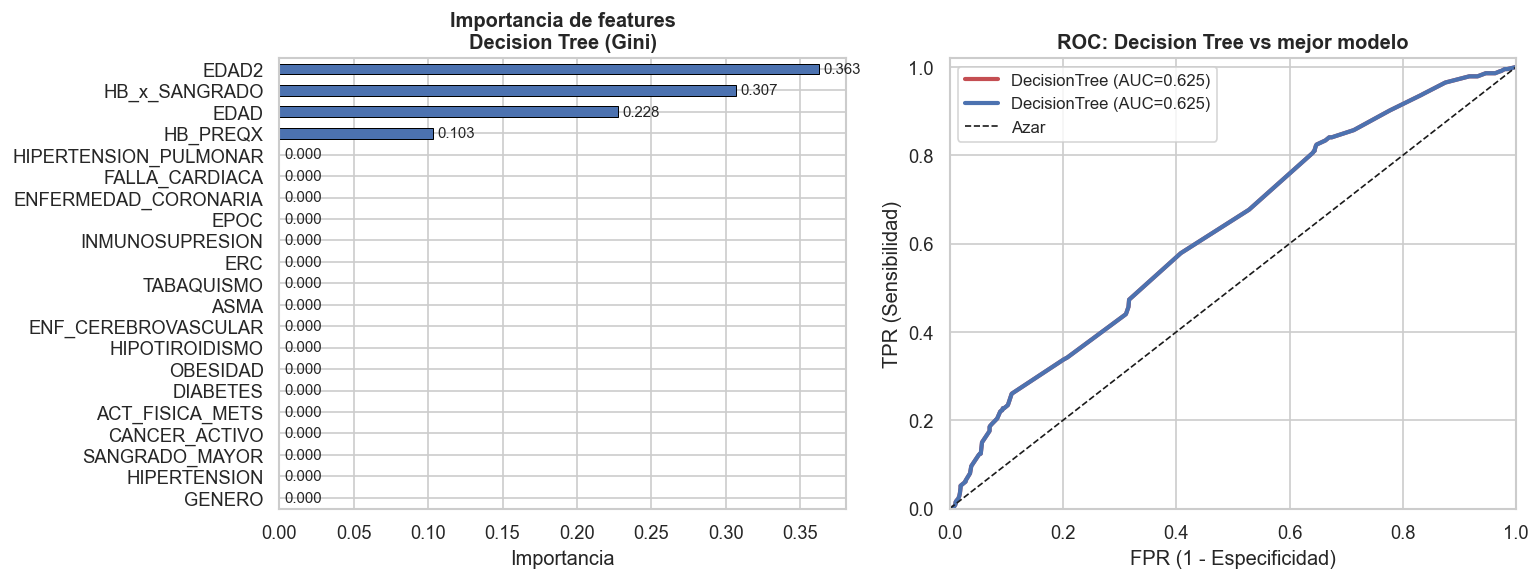


Nodos del árbol  : 27
Profundidad real : 4
Hojas            : 14
AUC-ROC (CV)     : 0.637 ± 0.035
AUC-ROC (OOF)    : 0.6250
H-L test         : H=172.018, p=0.0000  (mal calibrado ✗ — aplicar Platt scaling)


In [82]:
# ── Sección 14.5: Decision Tree — reglas e importancias ─────────────────────
#
# El Decision Tree tiene la ventaja única de producir reglas clínicas legibles
# directamente. Aquí se visualizan las reglas y sus importancias de features.

dt_model = copy.deepcopy(models['DecisionTree'])
dt_model.fit(X, y)

print('── Reglas del árbol de decisión (profundidad max=4) ──\n')
print(export_text(dt_model, feature_names=list(FEATURES), max_depth=4))

# Feature importance del árbol
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

importances = pd.Series(dt_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='#4C72B0', edgecolor='black', linewidth=0.6)
axes[0].set_title('Importancia de features\nDecision Tree (Gini)', fontweight='bold')
axes[0].set_xlabel('Importancia')
for i, v in enumerate(importances):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)

# Comparar AUC del árbol vs mejor modelo
_dt_probs = np.zeros(len(y))
for train_idx, test_idx in cv.split(X, y):
    m = copy.deepcopy(models['DecisionTree'])
    m.fit(X.iloc[train_idx], y.iloc[train_idx])
    _dt_probs[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y, _dt_probs)
auc_dt = roc_auc_score(y, _dt_probs)

fpr_b, tpr_b, _ = roc_curve(y, oof_probs[best_name])
auc_b  = roc_auc_score(y, oof_probs[best_name])

axes[1].plot(fpr_dt, tpr_dt, lw=2.5, color='#C44E52',
             label=f'DecisionTree (AUC={auc_dt:.3f})')
axes[1].plot(fpr_b,  tpr_b,  lw=2.5, color='#4C72B0',
             label=f'{best_name} (AUC={auc_b:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
axes[1].set_xlabel('FPR (1 - Especificidad)')
axes[1].set_ylabel('TPR (Sensibilidad)')
axes[1].set_title('ROC: Decision Tree vs mejor modelo', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

# Estadísticas del árbol
print(f'\nNodos del árbol  : {dt_model.tree_.node_count}')
print(f'Profundidad real : {dt_model.get_depth()}')
print(f'Hojas            : {dt_model.get_n_leaves()}')
dt_auc_cv = cv_results.get('DecisionTree', {}).get('test_AUC-ROC', np.array([auc_dt]))
print(f'AUC-ROC (CV)     : {dt_auc_cv.mean():.3f} ± {dt_auc_cv.std():.3f}')
print(f'AUC-ROC (OOF)    : {auc_dt:.4f}')

hl_dt, p_dt = hosmer_lemeshow(y.values, _dt_probs)
print(f'H-L test         : H={hl_dt:.3f}, p={p_dt:.4f}  '
      f'({"bien calibrado ✓" if p_dt > 0.05 else "mal calibrado ✗ — aplicar Platt scaling"})')

## 15. Resumen final

In [94]:
print('═' * 68)
print('  RESUMEN FINAL — Shock Hemorrágico Postoperatorio')
print('═' * 68)

# Info de features
print(f'Variables base ({len(FEATURES_BASE)}): {", ".join(FEATURES_BASE[:5])} + {len(FEATURES_BASE)-5} más')
print(f'Features totales ({len(FEATURES)}): incluye HB_x_SANGRADO, EDAD2')

# Info split
if all(v in globals() for v in ['X_train', 'X_test', 'y_train', 'y_test']):
    print(f'\nSplit holdout: TRAIN={len(y_train)} (prev={float(np.mean(y_train)):.3f}) | TEST={len(y_test)} (prev={float(np.mean(y_test)):.3f})')

# Selección en TRAIN
auc_cv = float(np.mean(cv_results[best_name]['test_AUC-ROC'])) if 'cv_results' in globals() else float('nan')
print(f'\nMejor modelo (selección en TRAIN, CV 5-fold): {best_name} | AUC-CV={auc_cv:.3f}')
print(f'Umbral Youden (TRAIN): {youden_thresh:.2f} (Sens={youden_sens:.3f}, Esp={youden_spec:.3f})')
if 'OPERATING_THRESHOLD' in globals():
    print(f'Umbral operativo aplicado: t={OPERATING_THRESHOLD:.2f}')

# ── RESULTADO FINAL: evaluación única en TEST holdout (10%) ─────────────────
print('\n' + '─' * 68)
print('  RESULTADO FINAL — TEST (holdout 10%)')
print('─' * 68)

if all(v in globals() for v in ['X_train', 'X_test', 'y_train', 'y_test', 'models', 'best_name']):
    _final_model = copy.deepcopy(models[best_name])
    _final_model.fit(X_train, y_train)
    y_test_prob = _final_model.predict_proba(X_test)[:, 1]
    _t = OPERATING_THRESHOLD if 'OPERATING_THRESHOLD' in globals() else 0.5
    y_test_pred = (y_test_prob >= _t).astype(int)
    cm_test = confusion_matrix(y_test, y_test_pred)
    tn, fp, fn, tp = cm_test.ravel()
    sens_test = tp / (tp + fn) if (tp + fn) else 0.0
    spec_test = tn / (tn + fp) if (tn + fp) else 0.0
    ppv_test  = tp / (tp + fp) if (tp + fp) else 0.0
    npv_test  = tn / (tn + fn) if (tn + fn) else 0.0
    print(f'AUC-ROC (TEST): {roc_auc_score(y_test, y_test_prob):.4f}')
    print(f'Sens (TEST): {sens_test:.4f} | Esp (TEST): {spec_test:.4f} | PPV: {ppv_test:.4f} | NPV: {npv_test:.4f}')
    print(f'Matriz (TEST) [TN FP; FN TP]: [{tn} {fp}; {fn} {tp}]')
else:
    print('[Aviso] No se encontraron variables de split (X_train/X_test). Ejecuta desde la sección 2 en orden.')

# Calibración (en TRAIN; útil para probabilidades absolutas y DCA)
_hl_probs = oof_probs_cal if 'oof_probs_cal' in globals() else oof_probs
print('\n── Calibración post-hoc (Hosmer-Lemeshow, TRAIN) ──')
print('Modelos recomendados para probabilidades absolutas (p>0.05):')
_warned_len = False
for name in models:
    if name not in _hl_probs:
        continue
    pvec = _hl_probs[name]
    if len(pvec) != len(y):
        if not _warned_len:
            print('  [Aviso] Probs de calibración desactualizadas vs TRAIN; re-ejecuta sección 13 para refrescar.')
            _warned_len = True
        continue
    _, p = hosmer_lemeshow(y.values, pvec)
    if p > 0.05:
        if '_WELL_CALIBRATED' in globals():
            remark = '(calibrado nativamente)' if name in _WELL_CALIBRATED else '(tras Platt scaling)'
        else:
            remark = ''
        print(f'  ✓ {name} {remark}')

print('\nNotas (TRIPOD): CV en TRAIN + TEST holdout 10%; validación externa pendiente.')

════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — Shock Hemorrágico Postoperatorio
════════════════════════════════════════════════════════════════════
Variables base (19): EDAD, GENERO, HB_PREQX, HIPERTENSION, CANCER_ACTIVO + 14 más
Features totales (21): incluye HB_x_SANGRADO, EDAD2

Split holdout: TRAIN=1191 (prev=0.322) | TEST=133 (prev=0.323)

Mejor modelo (selección en TRAIN, CV 5-fold): DecisionTree | AUC-CV=0.639
Umbral Youden (TRAIN): 0.51 (Sens=0.578, Esp=0.605)
Umbral operativo aplicado: t=0.51

────────────────────────────────────────────────────────────────────
  RESULTADO FINAL — TEST (holdout 10%)
────────────────────────────────────────────────────────────────────
AUC-ROC (TEST): 0.5804
Sens (TEST): 0.6977 | Esp (TEST): 0.3889 | PPV: 0.3529 | NPV: 0.7292
Matriz (TEST) [TN FP; FN TP]: [35 55; 13 30]

── Calibración post-hoc (Hosmer-Lemeshow, TRAIN) ──
Modelos recomendados para probabilidades absolutas (p>0.05):
  [Aviso] Probs de cali

In [99]:
# ── RESULTADO FINAL (compacto) — TEST holdout 10% ────────────────────────────
# Esta celda imprime SOLO las métricas finales para reporte, comparando umbrales.
def _eval_threshold(y_true, y_prob, t):
    y_pred = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) else 0.0
    npv  = tn / (tn + fn) if (tn + fn) else 0.0
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return {
        't': float(t),
        'AUC': float(roc_auc_score(y_true, y_prob)),
        'Sens': float(sens),
        'Esp': float(spec),
        'PPV': float(ppv),
        'NPV': float(npv),
        'F1': float(f1),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    }

_final_model = copy.deepcopy(models[best_name])
_final_model.fit(X_train, y_train)

test_prob = _final_model.predict_proba(X_test)[:, 1]

thresholds_to_report = []
thresholds_to_report.append(('0.50 (default)', 0.50))
if 'THRESH_YOUDEN' in globals():
    thresholds_to_report.append(('Youden (TRAIN)', float(THRESH_YOUDEN)))
elif 'youden_thresh' in globals():
    thresholds_to_report.append(('Youden (TRAIN)', float(youden_thresh)))
if 'THRESH_SENS80' in globals() and THRESH_SENS80 is not None:
    thresholds_to_report.append(('Sens≥0.80 (TRAIN)', float(THRESH_SENS80)))
if 'OPERATING_THRESHOLD' in globals():
    thresholds_to_report.append(('Operativo', float(OPERATING_THRESHOLD)))

# dedupe por valor de t
_seen = set()
thresholds_to_report_dedup = []
for label, t in thresholds_to_report:
    key = round(float(t), 6)
    if key in _seen:
        continue
    _seen.add(key)
    thresholds_to_report_dedup.append((label, float(t)))

print('FINAL TEST (holdout 10%)')
print(f'  Modelo: {best_name}')
print(f'  Prevalencia TEST: {float(np.mean(y_test)):.3f} | n={len(y_test)}')
print()
for label, t in thresholds_to_report_dedup:
    r = _eval_threshold(y_test, test_prob, t)
    print(f'- Umbral: {label} | t={r["t"]:.2f}')
    print(f'  AUC={r["AUC"]:.4f} | Sens={r["Sens"]:.4f} | Esp={r["Esp"]:.4f} | PPV={r["PPV"]:.4f} | NPV={r["NPV"]:.4f} | F1={r["F1"]:.4f}')
    print(f'  Matriz [TN FP; FN TP]: [{r["TN"]} {r["FP"]}; {r["FN"]} {r["TP"]}]')

FINAL TEST (holdout 10%)
  Modelo: DecisionTree
  Prevalencia TEST: 0.323 | n=133

- Umbral: 0.50 (default) | t=0.50
  AUC=0.5804 | Sens=0.6977 | Esp=0.3889 | PPV=0.3529 | NPV=0.7292 | F1=0.4688
  Matriz [TN FP; FN TP]: [35 55; 13 30]
- Umbral: Youden (TRAIN) | t=0.51
  AUC=0.5804 | Sens=0.6977 | Esp=0.3889 | PPV=0.3529 | NPV=0.7292 | F1=0.4688
  Matriz [TN FP; FN TP]: [35 55; 13 30]
- Umbral: Sens≥0.80 (TRAIN) | t=0.48
  AUC=0.5804 | Sens=0.6977 | Esp=0.3889 | PPV=0.3529 | NPV=0.7292 | F1=0.4688
  Matriz [TN FP; FN TP]: [35 55; 13 30]
